In [91]:
# Set to True to output analysis summaries, False to skip
SHOW_SUMMARY = False

# Datasource
https://docs.google.com/document/d/1B3Itxfko-DzyzQlF4_Qc73aSTrcPyLpaySRRyD7-EY0/edit?tab=t.0

- Github URL: https://github.com/darknet-doll/BKS_survey

# Import

In [92]:
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator
from scipy.stats import kruskal, mannwhitneyu, pointbiserialr

# pd.set_option("display.max_colwidth", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)

# Expand display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


In [93]:
df = pd.read_csv("../database/cgl_BKS_data.csv")
df = df.drop(columns='role_Nazis')
pd.set_option("display.max_info_columns", df.shape[1])

## Review Schema

# CGL Personality

In [94]:
df['cgl'].value_counts(dropna=False)

cgl
NaN    11363
0.0     1295
1.0      744
3.0      606
2.0      597
4.0      488
5.0      410
Name: count, dtype: int64

## CGL Sample Size

In [95]:
# Replace CGL NaN values with 0 and create a boolean flag for CGL presence.
df['cgl'] = df['cgl']

df['cgl_flag'] = np.where(
    df['cgl'] >= 1, True,
    np.where(df['cgl'] == 0, False, "Unknown")
)
# Extracting DF for CGL and non-CGL records.
cgl_df = df[df['cgl_flag'] == "True"]
non_cgl_df = df[df['cgl_flag'] == "False"]

In [96]:
cgl_count = cgl_df.shape[0]
non_cgl_count = non_cgl_df.shape[0]
unknown_count = (df['cgl_flag'] == 'Unknown').sum()

print(
    "Total records: ",
    df.shape[0],
    "\nTotal CGL positive records (True): ", 
    cgl_count,
    f'({cgl_count/df.shape[0]*100:.2f}%)',
    "\nTotal CGL negative records (False): ",
    non_cgl_count,
    f'({non_cgl_count/df.shape[0]*100:.2f}%)',
    "\nTotal records with unknown CGL data: ",
    unknown_count,
    f'({unknown_count/df.shape[0]*100:.2f}%)',
)


Total records:  15503 
Total CGL positive records (True):  2845 (18.35%) 
Total CGL negative records (False):  1295 (8.35%) 
Total records with unknown CGL data:  11363 (73.30%)


In [97]:
df.ds_preference.value_counts(dropna=False)
cgl_df.diagnosis.value_counts(dropna=False)

diagnosis
NaN                                 1873
Anxiety                              218
Depression                           167
ADHD                                 153
Social anxiety                       109
Body Dysmorphia                       51
Autism                                44
OCD                                   33
Borderline                            23
C-PTSD                                23
PTSD                                  22
Bipolar I                             21
Anorexia                              17
Bipolar II                            17
Substance Abuse Disorder              16
Sociopathy                            16
Disassociative Identity Disorder      14
Bulimia                               11
Depersonalization/derealization       10
Schizophrenia                          7
Name: count, dtype: int64

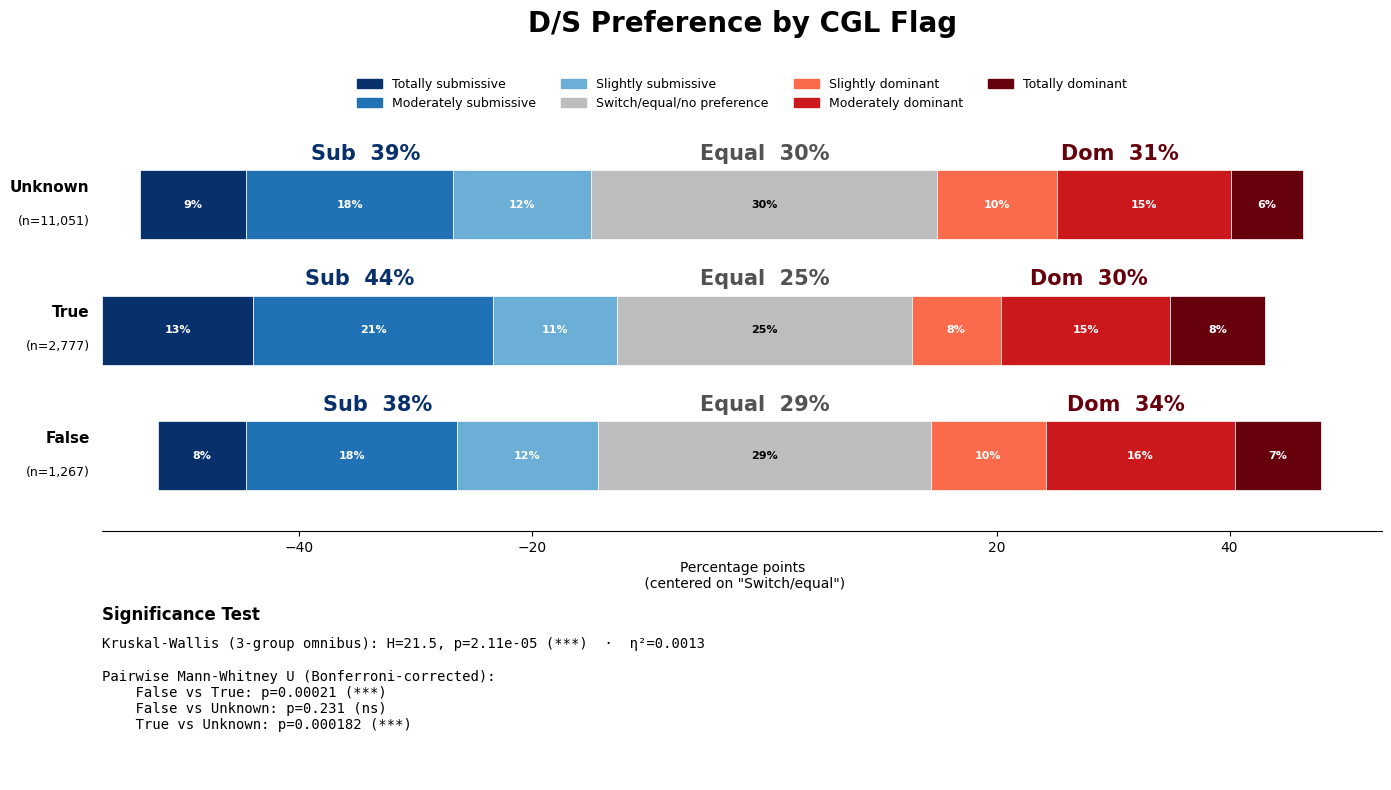

In [98]:
ds_order = [
    'Totally submissive',
    'Moderately submissive',
    'Slightly submissive',
    'Switch/equal/no preference',
    'Slightly dominant',
    'Moderately dominant',
    'Totally dominant',
]
ds_rank = {cat: i + 1 for i, cat in enumerate(ds_order)}

ds_colors = [
    '#08306b', '#2171b5', '#6baed6',
    '#bdbdbd',
    '#fb6a4a', '#cb181d', '#67000d',
]
color_map = dict(zip(ds_order, ds_colors))

plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)
plot_df = plot_df.dropna(subset=['ds_preference'])

flag_order = ['False', 'True', 'Unknown']
n_per_flag = plot_df['cgl_flag'].value_counts()

pivot = (
    pd.crosstab(plot_df['cgl_flag'], plot_df['ds_preference'], normalize='index')
    .mul(100)
    .reindex(index=flag_order, columns=ds_order, fill_value=0)
)

switch_idx = ds_order.index('Switch/equal/no preference')

fig, (ax_chart, ax_stats) = plt.subplots(
    2, 1, figsize=(14, 8),
    gridspec_kw={'height_ratios': [3, 1.3]},
)

# --- Diverging Likert chart ---
bar_height = 0.55
y_pos = np.arange(len(flag_order))

for row_i, flag in enumerate(flag_order):
    row = pivot.loc[flag]
    sub_total = row.iloc[:switch_idx].sum()
    equal_total = row.iloc[switch_idx]
    dom_total = row.iloc[switch_idx + 1:].sum()

    left_edge = -equal_total / 2 - sub_total
    cursor = left_edge
    for cat in ds_order:
        width = row[cat]
        ax_chart.barh(
            row_i, width, left=cursor, height=bar_height,
            color=color_map[cat], edgecolor='white', linewidth=0.5,
        )
        if width > 3:
            ax_chart.text(
                cursor + width / 2, row_i, f'{width:.0f}%',
                ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='white' if cat != 'Switch/equal/no preference' else 'black',
            )
        cursor += width

    sub_center = -equal_total / 2 - sub_total / 2
    equal_center = 0
    dom_center = equal_total / 2 + dom_total / 2
    label_y = row_i + bar_height / 2 + 0.05

    ax_chart.text(sub_center, label_y, f'Sub  {sub_total:.0f}%',
                  ha='center', va='bottom',
                  fontsize=15, fontweight='bold', color='#08306b')
    ax_chart.text(equal_center, label_y, f'Equal  {equal_total:.0f}%',
                  ha='center', va='bottom',
                  fontsize=15, fontweight='bold', color='#525252')
    ax_chart.text(dom_center, label_y, f'Dom  {dom_total:.0f}%',
                  ha='center', va='bottom',
                  fontsize=15, fontweight='bold', color='#67000d')

# Y-axis: hide default tick labels, manually place bold flag + regular (n=)
ax_chart.set_yticks(y_pos)
ax_chart.set_yticklabels([])
ax_chart.tick_params(axis='y', length=0)
ax_chart.set_ylim(-0.6, len(flag_order) - 0.4)

trans = ax_chart.get_yaxis_transform()
for i, flag in enumerate(flag_order):
    n = int(n_per_flag.get(flag, 0))
    ax_chart.text(-0.01, i + 0.08, flag,
                  transform=trans,
                  ha='right', va='bottom',
                  fontsize=11, fontweight='bold')
    ax_chart.text(-0.01, i - 0.08, f'(n={n:,})',
                  transform=trans,
                  ha='right', va='top',
                  fontsize=9, fontweight='normal')

# X-axis: remove the 0 tick mark/label
existing_ticks = ax_chart.get_xticks()
filtered_ticks = [t for t in existing_ticks if t != 0]
ax_chart.xaxis.set_major_locator(FixedLocator(filtered_ticks))

ax_chart.set_xlabel('Percentage points\n (centered on "Switch/equal")')
ax_chart.spines['top'].set_visible(False)
ax_chart.spines['right'].set_visible(False)
ax_chart.spines['left'].set_visible(False)

ax_chart.set_title(
    'D/S Preference by CGL Flag',
    fontsize=20, fontweight='bold', loc='center', pad=70
)

legend_handles = [Patch(color=ds_colors[i], label=ds_order[i]) for i in range(len(ds_order))]
ax_chart.legend(
    handles=legend_handles,
    bbox_to_anchor=(0.5, 1.02), loc='lower center',
    ncol=4, frameon=False, fontsize=9,
)

# --- Stats panel ---
def sig_marker(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def eta_squared_kw(h, k, n):
    return max(0.0, (h - k + 1) / (n - k)) if n > k else 0.0

plot_df['ds_rank'] = plot_df['ds_preference'].map(ds_rank)
groups = {f: plot_df.loc[plot_df['cgl_flag'] == f, 'ds_rank'].values for f in flag_order}
groups = {f: g for f, g in groups.items() if len(g) > 0}

stat, p_kw = kruskal(*groups.values())
n_total = sum(len(g) for g in groups.values())
eta = eta_squared_kw(stat, len(groups), n_total)

stat_lines = [
    f'Kruskal-Wallis (3-group omnibus): H={stat:.1f}, p={p_kw:.3g} ({sig_marker(p_kw)})  ·  η²={eta:.4f}',
    '\nPairwise Mann-Whitney U (Bonferroni-corrected):',
]
pairs = list(combinations(groups.keys(), 2))
for f1, f2 in pairs:
    _, p_pair = mannwhitneyu(groups[f1], groups[f2], alternative='two-sided')
    p_adj = min(p_pair * len(pairs), 1.0)
    stat_lines.append(f'    {f1} vs {f2}: p={p_adj:.3g} ({sig_marker(p_adj)})')

ax_stats.axis('off')
ax_stats.text(
    0.0, 1.0, 'Significance Test',
    transform=ax_stats.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold',
)
ax_stats.text(
    0.0, 0.82, '\n'.join(stat_lines),
    transform=ax_stats.transAxes,
    ha='left', va='top',
    family='monospace', fontsize=10,
)

plt.tight_layout()
plt.show()


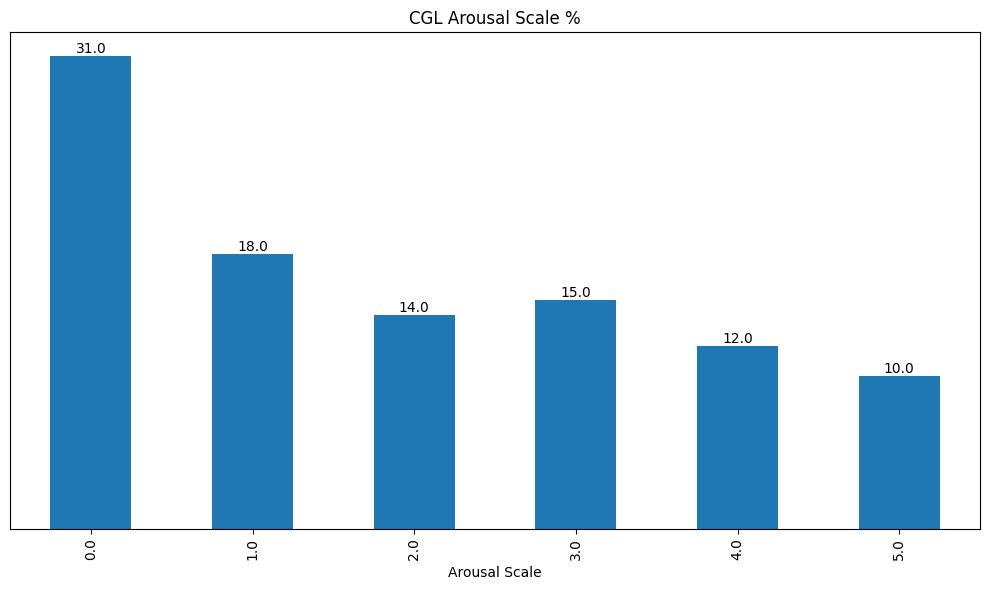

In [99]:
# Review CGL Arousal Scale distribution.
# df[df.cgl_flag==True]['cgl'].value_counts(normalize=True).round(2)*100

ax=(df["cgl"].value_counts(normalize=True).round(2) * 100).sort_index().plot(
    kind="bar", figsize=(10, 6), title="CGL Value Distribution"
)
# Formatting
ax.bar_label(ax.containers[0], fmt='%.1f')  # Add value labels
ax.get_yaxis().set_visible(False)
plt.xlabel("Arousal Scale")
plt.title("CGL Arousal Scale %")
plt.tight_layout()
plt.show()

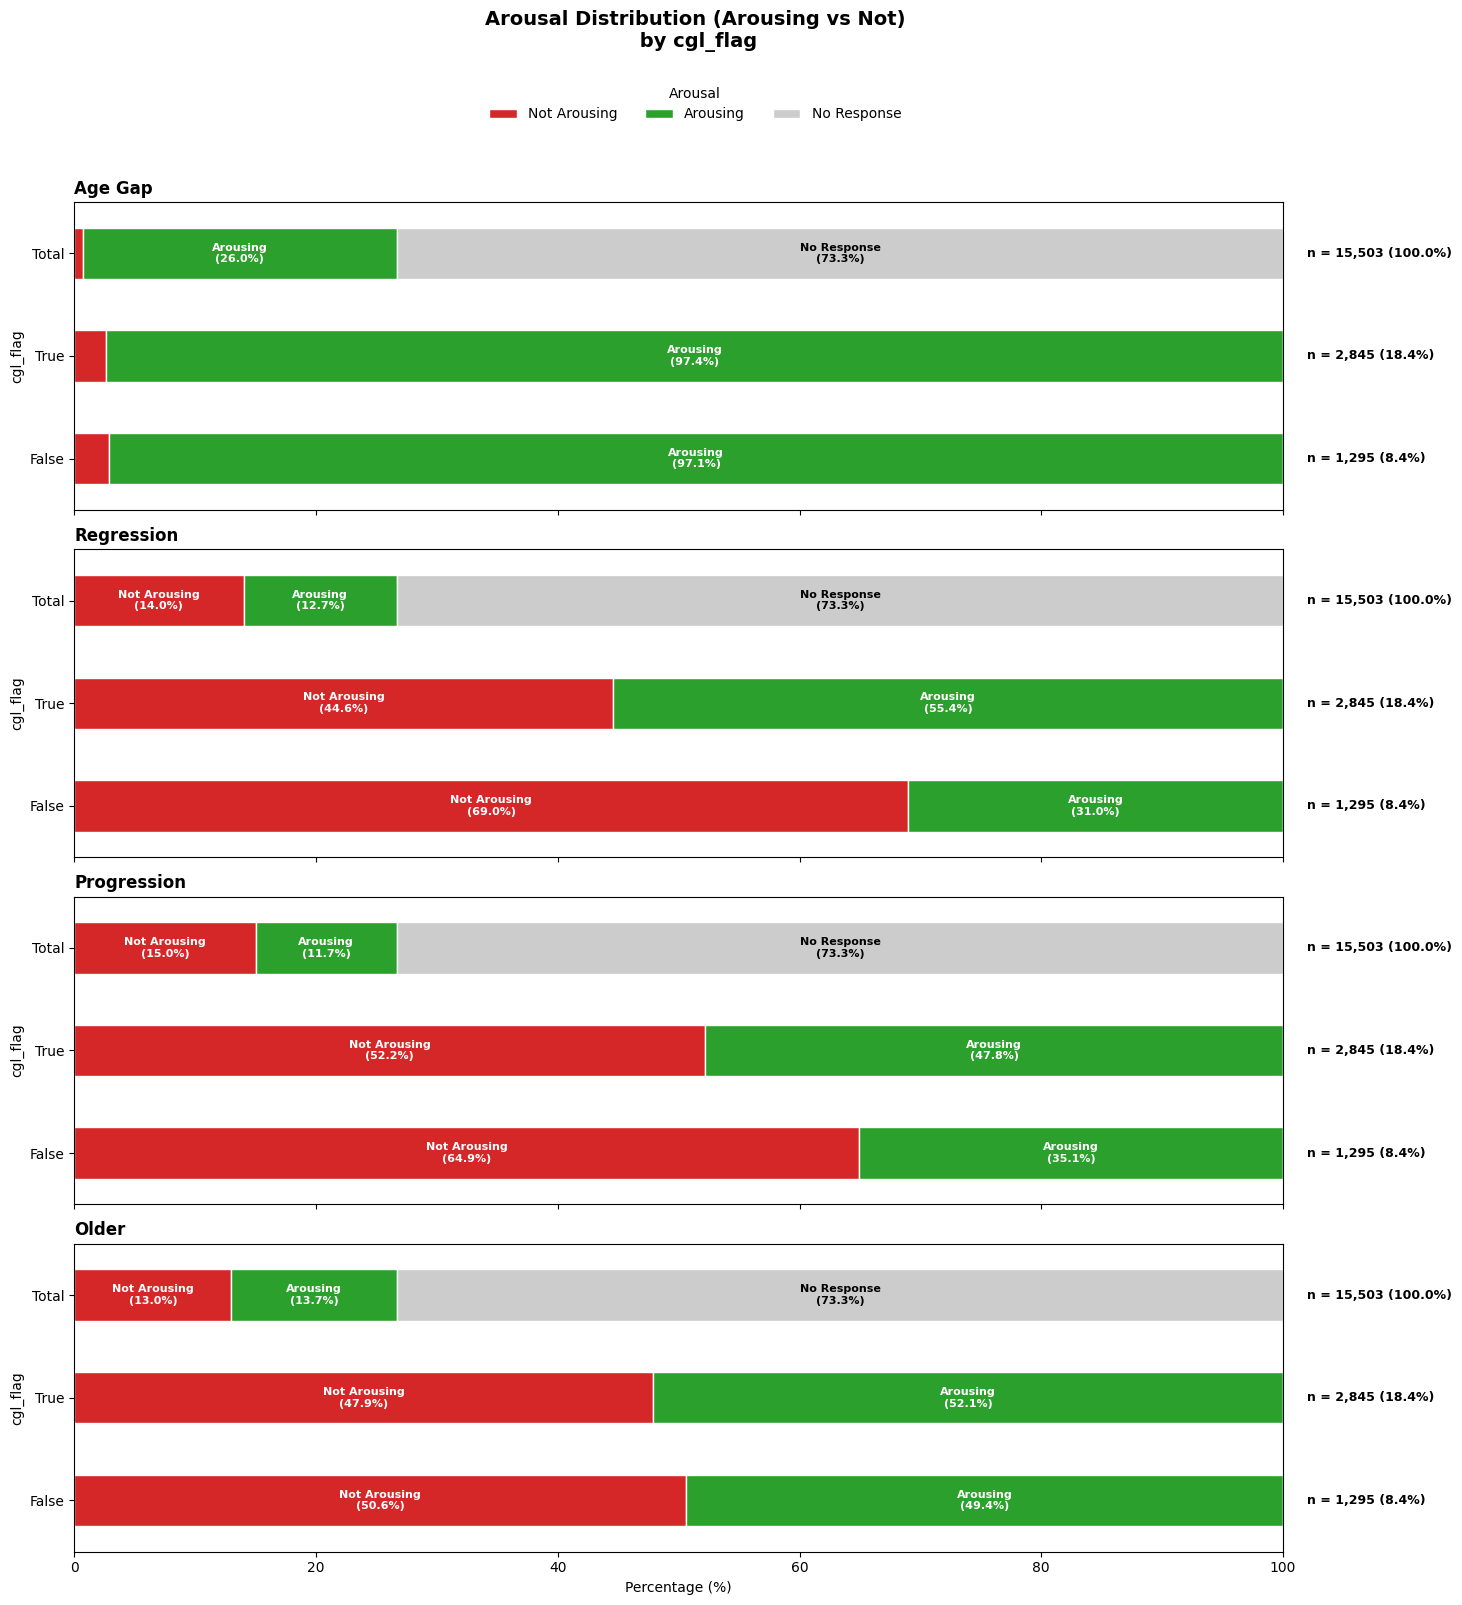

In [100]:
def plot_arousal_distribution(ax, df, col, title):
    """Plot arousal distribution (Arousing vs Not) for `col`, sliced by cgl_flag."""
    # Filter NaN only (keep 0 values)
    df_filtered = df.dropna(subset=[col]).copy()
    df_filtered[col] = df_filtered[col].astype(int)

    # Bucket into binary: 0 = "Not Arousing", 1-5 = "Arousing"
    df_filtered['arousal_bucket'] = df_filtered[col].apply(
        lambda x: 'Arousing' if x >= 1 else 'Not Arousing'
    )

    # Build crosstab for True/False only
    cgl_for_plot = df_filtered['cgl_flag'].astype(str)
    flag_pivot = (
        pd.crosstab(cgl_for_plot, df_filtered['arousal_bucket'], normalize='index')
        .mul(100)
        .round(1)
    )
    # Add a "No Response" column (0% for True/False since they have no NaN here)
    flag_pivot['No Response'] = 0.0
    # Reorder
    flag_pivot = flag_pivot.reindex(columns=['Not Arousing', 'Arousing', 'No Response'], fill_value=0)
    # Drop Unknown row if present
    flag_pivot = flag_pivot.drop(index='Unknown', errors='ignore')

    # Total row: based on ENTIRE df (df.shape[0]), bucketed including NaN as "No Response"
    def bucket_with_nan(x):
        if pd.isna(x):
            return 'No Response'
        elif x >= 1:
            return 'Arousing'
        else:
            return 'Not Arousing'
    
    total_buckets = df[col].apply(bucket_with_nan)
    total_dist = (
        total_buckets.value_counts(normalize=True)
        .mul(100)
        .round(1)
        .reindex(flag_pivot.columns, fill_value=0)
    )
    flag_pivot.loc['Total'] = total_dist

    flag_pivot.plot(
        kind='barh', stacked=True, ax=ax,
        color=['#d62728', '#2ca02c', '#cccccc'], edgecolor='white', legend=False,
    )

    ax.set_title(title, fontweight='bold', loc='left')
    ax.set_xlim(0, 100)
    ax.set_ylabel('cgl_flag')

    # Segment labels
    for i, container in enumerate(ax.containers):
        bucket_label = flag_pivot.columns[i]
        labels = [f'{bucket_label}\n({v:.1f}%)' if v > 3 else '' for v in flag_pivot.iloc[:, i]]
        text_color = 'black' if bucket_label == 'No Response' else 'white'
        ax.bar_label(container, labels=labels, label_type='center',
                     fontsize=8, color=text_color, fontweight='bold')

    # n= labels on the right (with % of total df)
    counts_per_flag = cgl_for_plot.value_counts()
    total_df = df.shape[0]
    for i, flag in enumerate(flag_pivot.index):
        if flag == 'Total':
            count = total_df  # Entire df
        else:
            count = counts_per_flag.get(flag, 0)
        pct_of_total = (count / total_df * 100)
        ax.text(
            1.02, i, f'n = {count:,} ({pct_of_total:.1f}%)',
            transform=ax.get_yaxis_transform(),
            ha='left', va='center',
            fontsize=9, fontweight='bold',
        )

    return flag_pivot


# Define the metrics: (column_name, display_title)
metrics = [
    ('agegap', 'Age Gap'),
    ('regression', 'Regression'),
    ('progression', 'Progression'), 
    ('older', 'Older')
]

# Create stacked subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 4 * len(metrics)), sharex=True)

last_pivot = None
for ax, (col, title) in zip(axes, metrics):
    last_pivot = plot_arousal_distribution(ax, df, col, title)

axes[-1].set_xlabel('Percentage (%)')

# Single shared legend at the top of the figure
fig.legend(
    handles=axes[0].containers,
    labels=[str(c) for c in last_pivot.columns],
    title='Arousal',
    bbox_to_anchor=(0.5, 0.96),
    loc='upper center',
    ncol=len(last_pivot.columns),
    frameon=False,
)

fig.suptitle('Arousal Distribution (Arousing vs Not)\n by cgl_flag',
             fontweight='bold', fontsize=14, y=1.0)

plt.tight_layout()
plt.subplots_adjust(top=0.88, right=0.92)
plt.show()


## CGL Roles Distribution

### Roles Interest

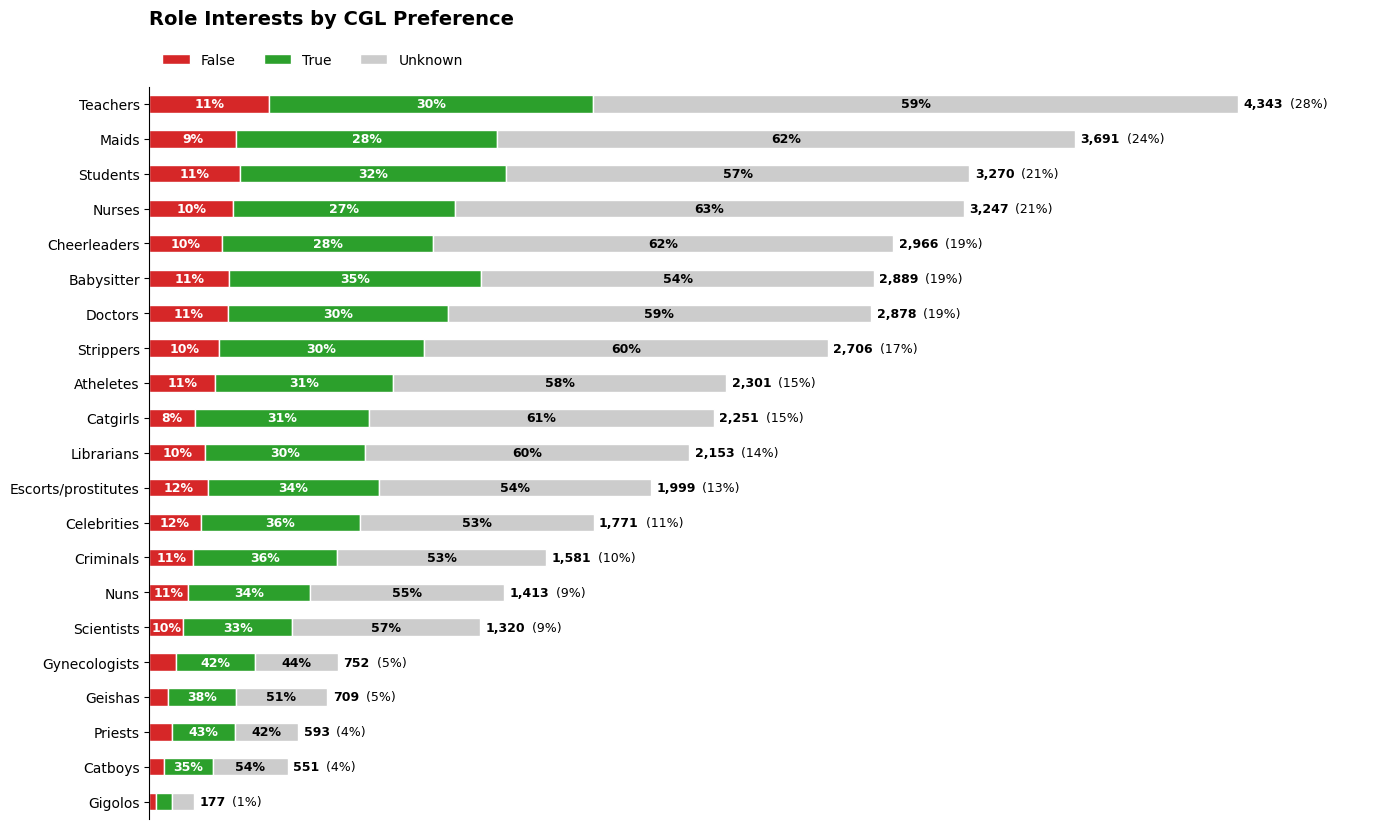

In [101]:
# Build counts: rows = role, columns = cgl_flag (True/False/Unknown)
role_cols = df.filter(like='role_').columns.tolist()
role_by_flag = df.groupby('cgl_flag')[role_cols].sum().T
role_by_flag = role_by_flag.fillna(0).astype(int)
role_by_flag.index = role_by_flag.index.str.replace('role_', '', regex=False)

# Total per role
role_totals = role_by_flag.sum(axis=1)

# % within each role (rows sum to 100)
role_pct = role_by_flag.div(role_totals, axis=0).mul(100).round(0)

# Order: False, True, Unknown
role_pct = role_pct.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)
role_by_flag = role_by_flag.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)

# Sort by total n ascending (highest n at top of barh)
sorted_index = role_totals.sort_values(ascending=True).index
role_pct = role_pct.loc[sorted_index]
role_by_flag = role_by_flag.loc[sorted_index]
role_totals = role_totals.loc[sorted_index]

# Plot raw counts (so bar length = n) — stacked
fig, ax = plt.subplots(figsize=(14, max(6, 0.4 * len(role_by_flag))))

role_by_flag.plot(
    kind='barh', stacked=True, ax=ax,
    color=['#d62728', '#2ca02c', '#cccccc'],  # False=red, True=green, Unknown=gray
    edgecolor='white', legend=False,
)

# Title with extra pad to leave room for legend below it
ax.set_title('Role Interests by CGL Preference',
             fontweight='bold', fontsize=14, loc='left', pad=45)
ax.set_ylabel('')

# Remove x-axis
ax.set_xlabel('')
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Segment labels inside bars: % only
for i, container in enumerate(ax.containers):
    flag_label = role_by_flag.columns[i]
    pct_values = role_pct.iloc[:, i].values
    n_values = role_by_flag.iloc[:, i].values
    min_n_for_label = role_totals.max() * 0.03
    labels = [
        f'{p:.0f}%' if n > min_n_for_label else ''
        for p, n in zip(pct_values, n_values)
    ]
    text_color = 'black' if flag_label == 'Unknown' else 'white'
    ax.bar_label(container, labels=labels, label_type='center',
                 fontsize=9, color=text_color, fontweight='bold')

# Right-side labels: n-count bold, % not bold
total_df = df.shape[0]
xmax = role_totals.max()
ax.set_xlim(0, xmax * 1.13)
for i, role in enumerate(role_pct.index):
    count = int(role_totals.loc[role])
    pct_of_total = (count / total_df * 100)
    n_text = ax.text(
        count + xmax * 0.005, i, f'{count:,}',
        ha='left', va='center',
        fontsize=9, fontweight='bold',
    )
    ax.annotate(
        f' ({pct_of_total:.0f}%)',
        xy=(1, 0.5), xycoords=n_text,
        xytext=(2, 0), textcoords='offset points',
        ha='left', va='center', fontsize=9,
    )

# Legend below title (no legend title to keep it compact, single row)
ax.legend(
    bbox_to_anchor=(0, 1.01),
    loc='lower left',
    ncol=3,
    frameon=False,
    fontsize=10,
)

plt.tight_layout()
plt.show()


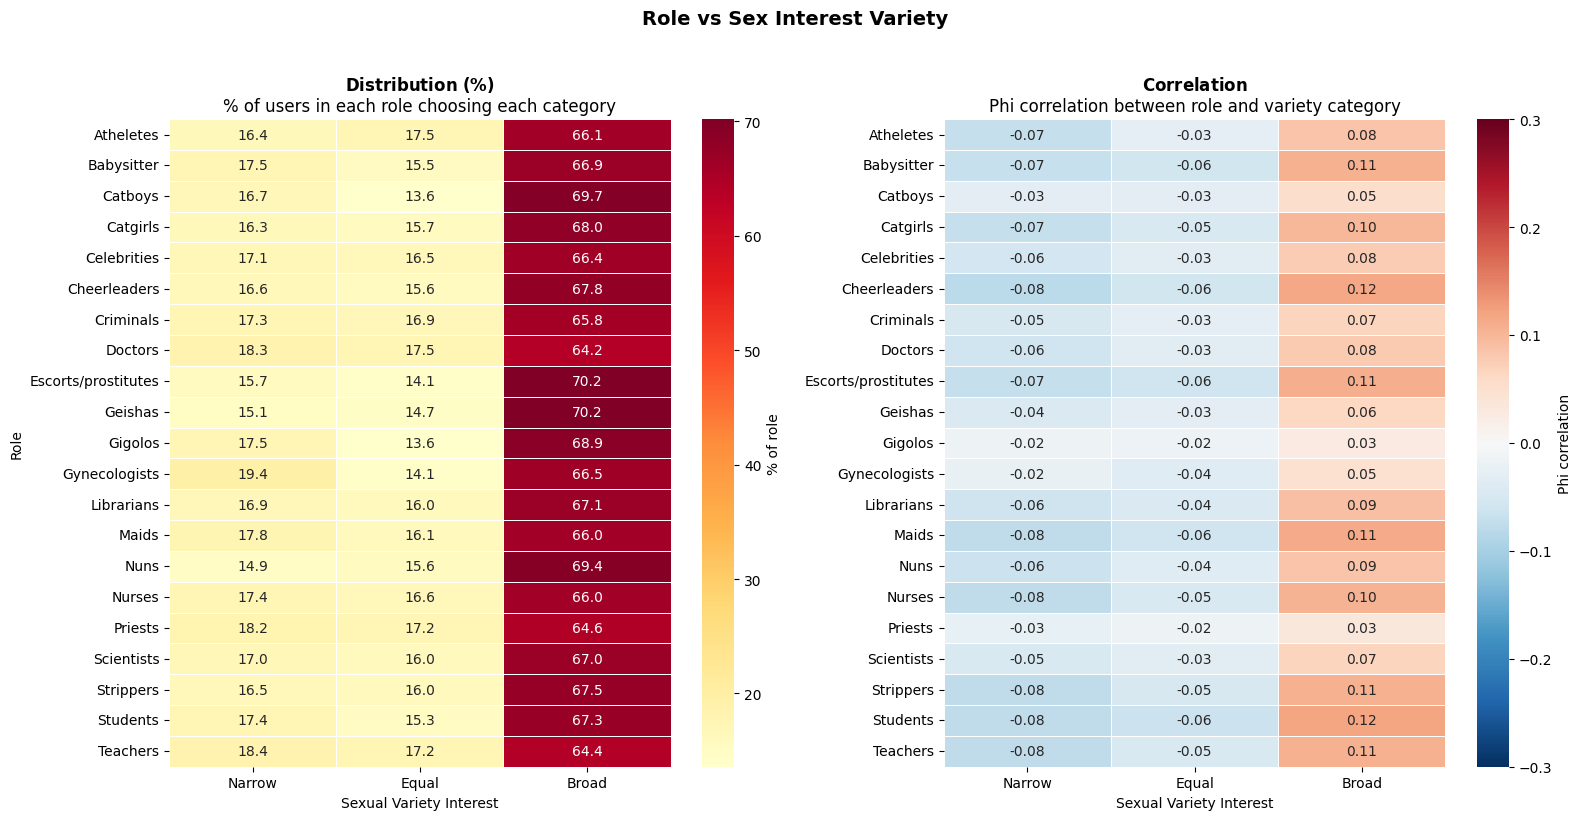

In [102]:
# ===== Collapse variety to 3 levels =====
variety_3_map = {
    'Very narrow': 'Narrow',
    'A little narrow': 'Narrow',
    'Somewhat narrow': 'Narrow',
    'Equally narrow and broad': 'Equal',
    'A little broad': 'Broad',
    'Somewhat broad': 'Broad',
    'Very broad': 'Broad',
}
df['variety_3'] = df['sexual_interest_variety'].map(variety_3_map)
variety_order = ['Narrow', 'Equal', 'Broad']

role_cols = df.filter(like='role_').columns.tolist()

# ===== LEFT: % distribution =====
rows = []
for r_col in role_cols:
    subset = df[df[r_col] == 1]
    if len(subset) > 0:
        dist = (
            subset['variety_3']
            .value_counts(normalize=True)
            .mul(100)
            .round(1)
        )
        dist.name = r_col.replace('role_', '')
        rows.append(dist)

pct_data = (
    pd.concat(rows, axis=1).T.fillna(0)
    .reindex(columns=variety_order, fill_value=0)
    .sort_index()
)

# ===== RIGHT: phi correlation =====
variety_dummies = pd.get_dummies(df['variety_3']).reindex(
    columns=variety_order, fill_value=0
)

corr_matrix = pd.DataFrame(
    index=[c.replace('role_', '') for c in role_cols],
    columns=variety_order,
    dtype=float,
)
for r_col in role_cols:
    for v_cat in variety_order:
        corr_matrix.loc[r_col.replace('role_', ''), v_cat] = df[r_col].corr(variety_dummies[v_cat])

corr_matrix = corr_matrix.astype(float).sort_index()

# ===== Plot side by side =====
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    pct_data, annot=True, fmt='.1f',
    cmap='YlOrRd', cbar_kws={'label': '% of role'},
    linewidths=0.5, linecolor='white', ax=axes[0],
)
axes[0].set_title(r"$\bf{Distribution\ (\%)}$" "\n% of users in each role choosing each category")
axes[0].set_xlabel('Sexual Variety Interest')
axes[0].set_ylabel('Role')
plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[0].get_yticklabels(), rotation=0)

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
    cbar_kws={'label': 'Phi correlation'},
    linewidths=0.5, linecolor='white', ax=axes[1],
)
axes[1].set_title(r"$\bf{Correlation}$" "\nPhi correlation between role and variety category")
axes[1].set_xlabel('Sexual Variety Interest')
axes[1].set_ylabel('')
plt.setp(axes[1].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[1].get_yticklabels(), rotation=0)

fig.suptitle('Role vs Sex Interest Variety', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


How to read this chart
──────────────────────
LEFT  (Distribution %): For each role, the share of its users who picked Sub /
      Equal / Dom. Rows sum to 100%. Rows are ordered by n (largest role on top).
      Color (custom non-linear ramp, scale 0% → 50%):
        0-20%   : near-white — values stay quiet
        20-30%  : near-white with a faint blue tint
        30-40%  : light teal — values start to register
        40-45%  : medium-dark teal — clearly elevated
        45-50%  : deep navy — strong concentration

RIGHT (D/s Lean): the role's average position on the original 1-7 D/s scale,
      shifted so 0 = "Switch/equal/no preference". Units are scale steps:
        +1.0 = on average, one step toward Dominant from Equal
        -1.5 = halfway between Slightly and Moderately Submissive
        ±3.0 = the maximum possible (everyone in the role picked the extreme)
      Significance: * p<.05, ** p<.01, *** p<.001. With this n, almost
      everything is significant — magnitude is 

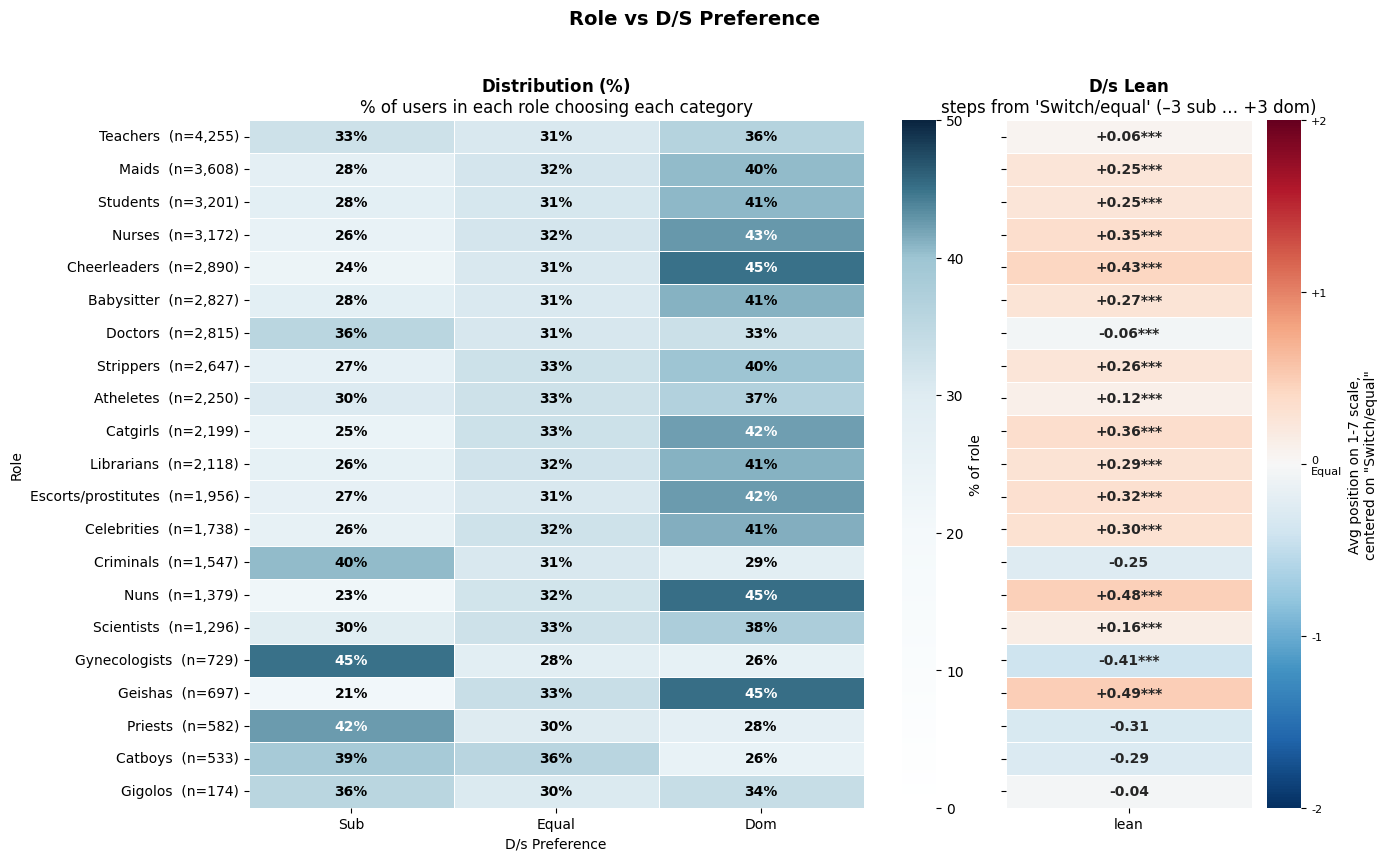

In [103]:
# ===== Role vs D/s Preference (collapsed to 3 levels) =====
# LEFT  panel: 3-level distribution heatmap (Sub / Equal / Dom)
# RIGHT panel: D/s Lean = mean ds_rank for the role minus the "Switch/equal" anchor

# ----- How to read this chart -----
print("""\
How to read this chart
──────────────────────
LEFT  (Distribution %): For each role, the share of its users who picked Sub /
      Equal / Dom. Rows sum to 100%. Rows are ordered by n (largest role on top).
      Color (custom non-linear ramp, scale 0% → 50%):
        0-20%   : near-white — values stay quiet
        20-30%  : near-white with a faint blue tint
        30-40%  : light teal — values start to register
        40-45%  : medium-dark teal — clearly elevated
        45-50%  : deep navy — strong concentration

RIGHT (D/s Lean): the role's average position on the original 1-7 D/s scale,
      shifted so 0 = "Switch/equal/no preference". Units are scale steps:
        +1.0 = on average, one step toward Dominant from Equal
        -1.5 = halfway between Slightly and Moderately Submissive
        ±3.0 = the maximum possible (everyone in the role picked the extreme)
      Significance: * p<.05, ** p<.01, *** p<.001. With this n, almost
      everything is significant — magnitude is what matters.

Why the lean uses the 1-7 scale (not the 3-level collapse): the score weights
"Totally" more than "Slightly", so a role full of Totally-dominants gets a
stronger lean than one of Slightly-dominants — even though both look 100% Dom
in the left panel.\
""")


# Custom cmap, anchored to vmax=50. Stop positions = absolute % / 50.
# Data tops out around 50%, so the full cmap range is spent on real values.
pct_cmap = LinearSegmentedColormap.from_list(
    'pct_cmap',
    [
        (0.00, '#ffffff'),  #  0%  pure white
        (0.40, '#f4f9fb'),  # 20%  very near-white
        (0.60, '#dfecf2'),  # 30%  near-white, faint blue tint
        (0.80, '#9ec5d3'),  # 40%  light teal
        (0.90, '#3a738a'),  # 45%  medium-dark teal
        (1.00, '#0a2540'),  # 50%  deep navy
    ],
)

# Collapse 7 → 3 levels
ds_3_map = {
    'Totally submissive':         'Sub',
    'Moderately submissive':      'Sub',
    'Slightly submissive':        'Sub',
    'Switch/equal/no preference': 'Equal',
    'Slightly dominant':          'Dom',
    'Moderately dominant':        'Dom',
    'Totally dominant':           'Dom',
}
df['ds_3'] = df['ds_preference'].map(ds_3_map)
ds_3_order = ['Sub', 'Equal', 'Dom']

role_cols = df.filter(like='role_').columns.tolist()

# ----- LEFT: % distribution per role across Sub/Equal/Dom -----
rows, n_per_role = [], {}
for r_col in role_cols:
    subset = df[(df[r_col] == 1) & df['ds_3'].notna()]
    n_per_role[r_col.replace('role_', '')] = len(subset)
    if len(subset) > 0:
        dist = subset['ds_3'].value_counts(normalize=True).mul(100).round(1)
        dist.name = r_col.replace('role_', '')
        rows.append(dist)

pct_data = (
    pd.concat(rows, axis=1).T.fillna(0)
      .reindex(columns=ds_3_order, fill_value=0)
)

# ----- RIGHT: D/s Lean = mean(ds_rank for role) − rank("Switch/equal") -----
EQUAL_RANK = ds_rank['Switch/equal/no preference']  # = 4
ds_rank_series = df['ds_preference'].map(ds_rank)
mask = ds_rank_series.notna()

lean_rows = []
for r_col in role_cols:
    role_mask = (df[r_col] == 1) & mask
    if role_mask.sum() == 0:
        continue
    mean_rank = ds_rank_series[role_mask].mean()
    _, p = pointbiserialr(df.loc[mask, r_col].astype(int), ds_rank_series.loc[mask])
    lean_rows.append({
        'role': r_col.replace('role_', ''),
        'lean': mean_rank - EQUAL_RANK,
        'p': p,
    })
lean_df = pd.DataFrame(lean_rows).set_index('role')

# Sort by sample size (n) descending — largest roles at the top
sort_order = pd.Series(n_per_role).sort_values(ascending=False).index
pct_data = pct_data.reindex(sort_order)
lean_df = lean_df.reindex(sort_order)

# Append n to y-axis labels
y_labels = [f'{role}  (n={n_per_role.get(role, 0):,})' for role in pct_data.index]
pct_data.index = y_labels
lean_df.index = y_labels

# Lean panel: floor at ±2 so small leans stay readable
vbound = max(2.0, float(lean_df['lean'].abs().max()))

# ----- Plot side by side -----
fig, axes = plt.subplots(
    1, 2, figsize=(14, max(6, 0.4 * len(pct_data))),
    gridspec_kw={'width_ratios': [3, 1.2]},
    sharey=True,
)

# --- Left: custom cmap on 0-50 scale.
sns.heatmap(
    pct_data, annot=False,
    cmap=pct_cmap,
    vmin=0, vmax=50,
    cbar_kws={'label': '% of role', 'ticks': [0, 10, 20, 30, 40, 50]},
    linewidths=0.5, linecolor='white', ax=axes[0],
)

# Adaptive annotation: black text on light cells, white on dark. Crossover ~42%.
WHITE_TEXT_THRESHOLD = 42
for i in range(pct_data.shape[0]):
    for j in range(pct_data.shape[1]):
        v = pct_data.iloc[i, j]
        axes[0].text(
            j + 0.5, i + 0.5, f'{v:.0f}%',
            ha='center', va='center',
            color='white' if v >= WHITE_TEXT_THRESHOLD else 'black',
            fontweight='bold', fontsize=10,
        )

axes[0].set_title(r"$\bf{Distribution\ (\%)}$" "\n% of users in each role choosing each category")
axes[0].set_xlabel('D/s Preference')
axes[0].set_ylabel('Role')
plt.setp(axes[0].get_xticklabels(), rotation=0, ha='center')
plt.setp(axes[0].get_yticklabels(), rotation=0)

# --- Right: D/s Lean as a single column. Diverging cmap centered on 0 (= Switch/equal).
def sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

annot = lean_df.apply(lambda row: f"{row['lean']:+.2f}{sig(row['p'])}", axis=1).to_frame('lean')

cbar_ticks = [-3, -2, -1, 0, 1, 2, 3]
cbar_labels = ['-3\nTotally\nSub', '-2', '-1', '0\nEqual', '+1', '+2', '+3\nTotally\nDom']

sns.heatmap(
    lean_df[['lean']], annot=annot, fmt='',
    cmap='RdBu_r', center=0, vmin=-vbound, vmax=vbound,
    cbar_kws={
        'label': 'Avg position on 1-7 scale,\ncentered on "Switch/equal"',
        'ticks': cbar_ticks,
    },
    linewidths=0.5, linecolor='white', ax=axes[1],
    annot_kws={'fontweight': 'bold'},
)
axes[1].collections[0].colorbar.ax.set_yticklabels(cbar_labels, fontsize=8)

axes[1].set_title(r"$\bf{D/s\ Lean}$" "\nsteps from 'Switch/equal' (–3 sub … +3 dom)")
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_xticklabels(['lean'])
plt.setp(axes[1].get_yticklabels(), rotation=0)

fig.suptitle('Role vs D/S Preference', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## CGL Emotional Erotic Desires 

### Soft Erotic Preferences

In [104]:
### Not many ppl answered --> not useful

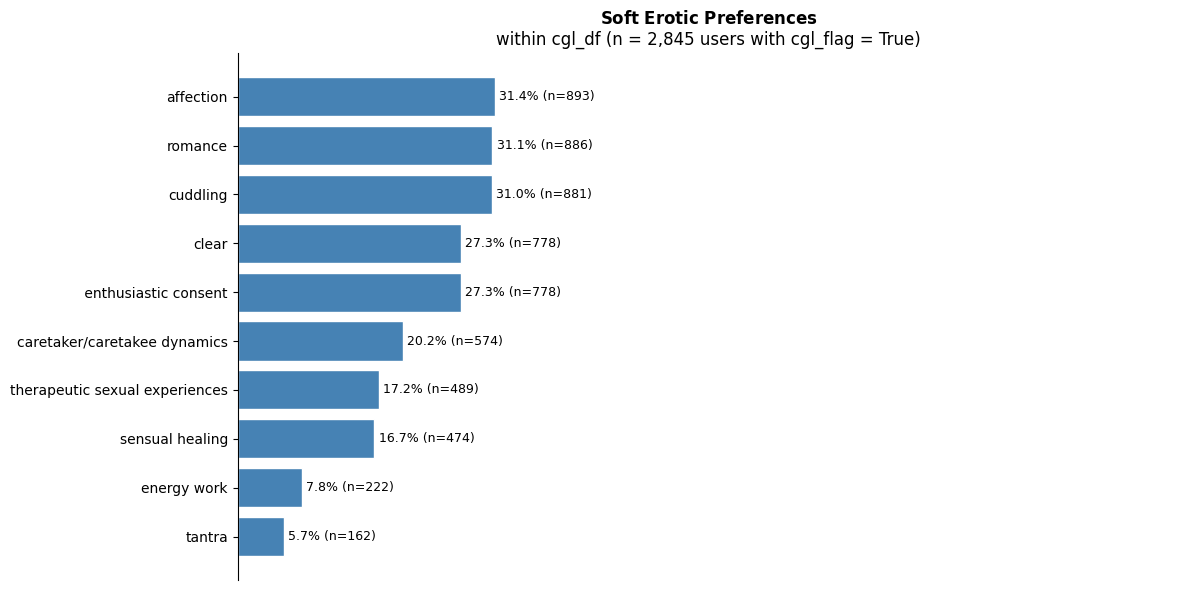

In [105]:
soft_erotic_cols = cgl_df.filter(like='soft_erotic_').columns.tolist()

# Calculate counts and percentages
data = pd.DataFrame({
    'pct': (cgl_df[soft_erotic_cols].mean() * 100).round(1),
    'count': cgl_df[soft_erotic_cols].sum().astype(int),
})

# Strip prefix
data.index = data.index.str.replace(r'^(soft_erotic_)+', '', regex=True)

# Sort ascending (highest at top of horizontal bar)
data = data.sort_values('pct', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, max(6, len(data) * 0.35)))
ax.barh(data.index, data['pct'], color='steelblue', edgecolor='white')

ax.set_title(
    r"$\bf{Soft\ Erotic\ Preferences}$"
    f"\nwithin cgl_df (n = {len(cgl_df):,} users with cgl_flag = True)"
)

# Hide x-axis (ticks, label, and surrounding spines)
ax.set_xticks([])
ax.set_xlabel('')
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Data labels: "85.3% (n=2,361)"
labels = [f'{p:.1f}% (n={n:,})' for p, n in zip(data['pct'], data['count'])]
ax.bar_label(ax.containers[0], labels=labels, padding=3, fontsize=9)

# Extra room on the right so labels don't get clipped
ax.set_xlim(0, 115)

plt.tight_layout()
plt.show()


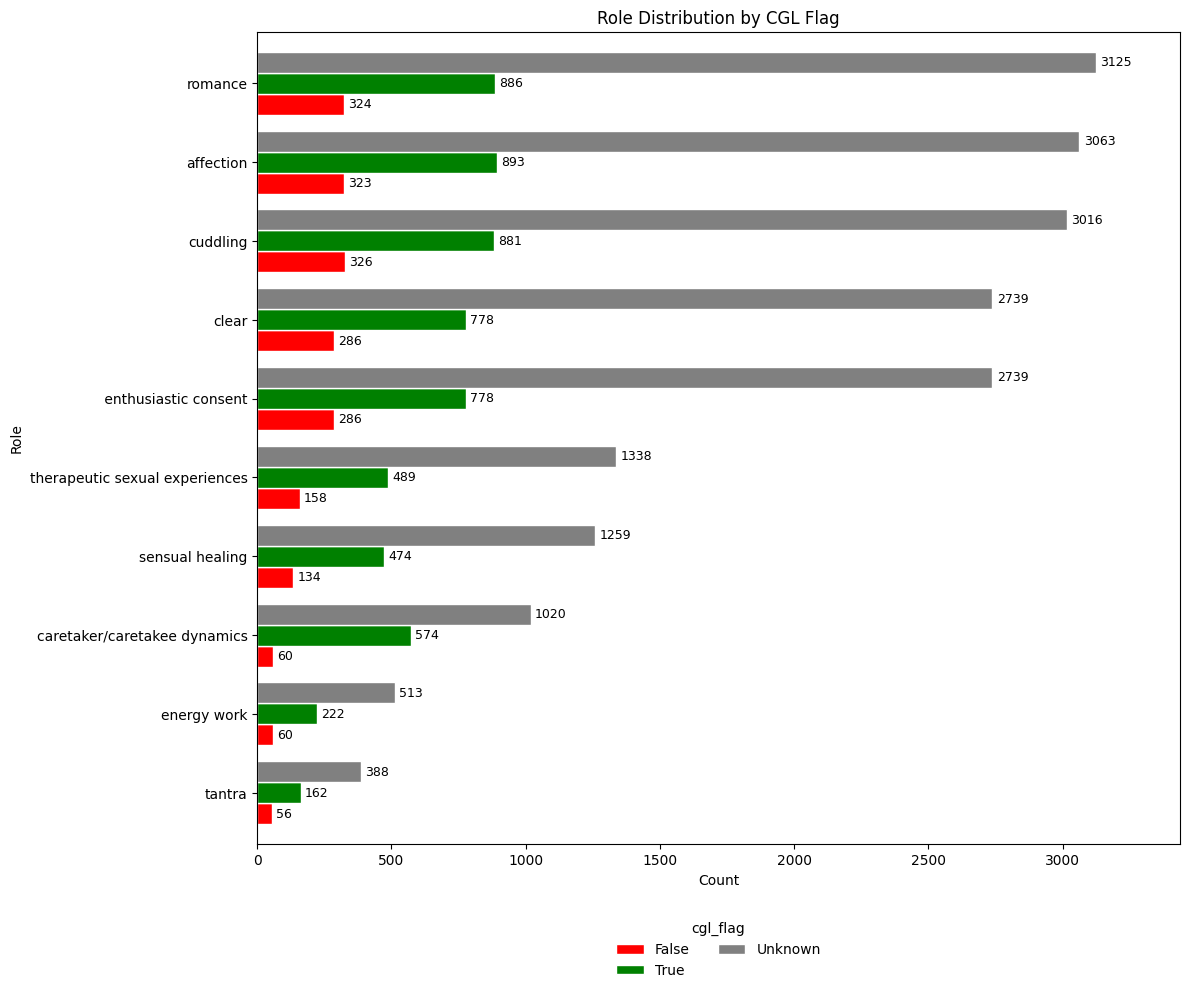

In [106]:
# Use the FULL dataframe (df), not the filtered cgl_df
role_cols = df.filter(like='soft_erotic_').columns.tolist()
role_by_flag = df.groupby('cgl_flag')[role_cols].sum().T

role_by_flag = role_by_flag.sort_index(axis=1).fillna(0).astype(int)
role_by_flag.index = role_by_flag.index.str.replace('soft_erotic_', '', regex=False)
role_by_flag = role_by_flag.loc[role_by_flag.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 10))
role_by_flag.plot(
    kind='barh',
    ax=ax,
    color=['red', 'green', 'gray'],  # False=red, True=green, Unknown=gray
    edgecolor='white',
    width=0.8,
)

ax.set_title('Role Distribution by CGL Flag')
ax.set_xlabel('Count')
ax.set_ylabel('Role')
ax.legend(title='cgl_flag', bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=2, frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

xmax = role_by_flag.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.1)

plt.tight_layout()
plt.show()


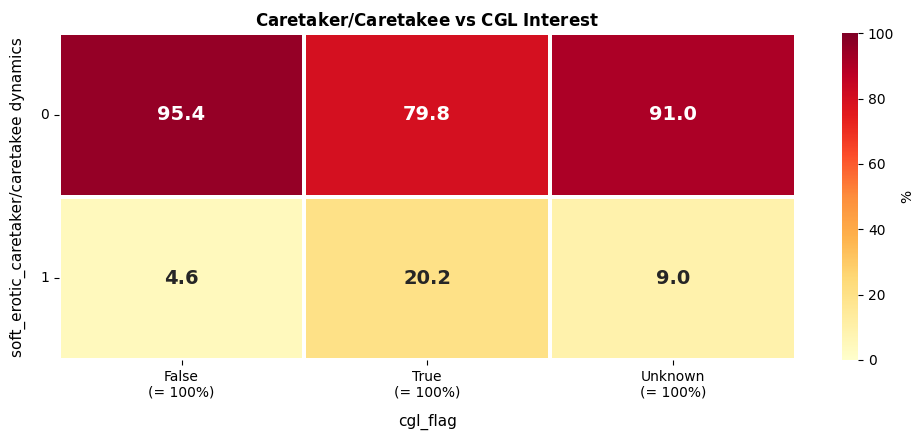

In [107]:
# === Adjust to match your column ===
care_col = 'soft_erotic_caretaker/caretakee dynamics'
# ===================================

# Column-normalized: each cgl_flag column sums to 100%
breakdown = (
    pd.crosstab(df[care_col], df['cgl_flag'], normalize='columns')
    .mul(100)
    .round(1)
    .sort_index(axis=1)
    .sort_index(axis=0)
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(
    breakdown,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': '%'},
    linewidths=1.5, linecolor='white',
    ax=ax,
    vmin=0, vmax=100,
    annot_kws={'fontsize': 14, 'fontweight': 'bold'},
)

# Short x-tick labels (just the flag value, with column total below)
col_totals = breakdown.sum(axis=0)
new_xticklabels = [
    f'{col}\n(= {total:.0f}%)'
    for col, total in zip(breakdown.columns, col_totals)
]
ax.set_xticklabels(new_xticklabels)

# Short y-tick labels (just the value)
ax.set_yticklabels(breakdown.index)

ax.set_title(
    r"$\bf{Caretaker/Caretakee\ vs\ CGL\ Interest}$"
)
ax.set_xlabel('cgl_flag', fontsize=11, labelpad=10)
ax.set_ylabel(care_col, fontsize=11, labelpad=10)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


### You/Other Feel Most

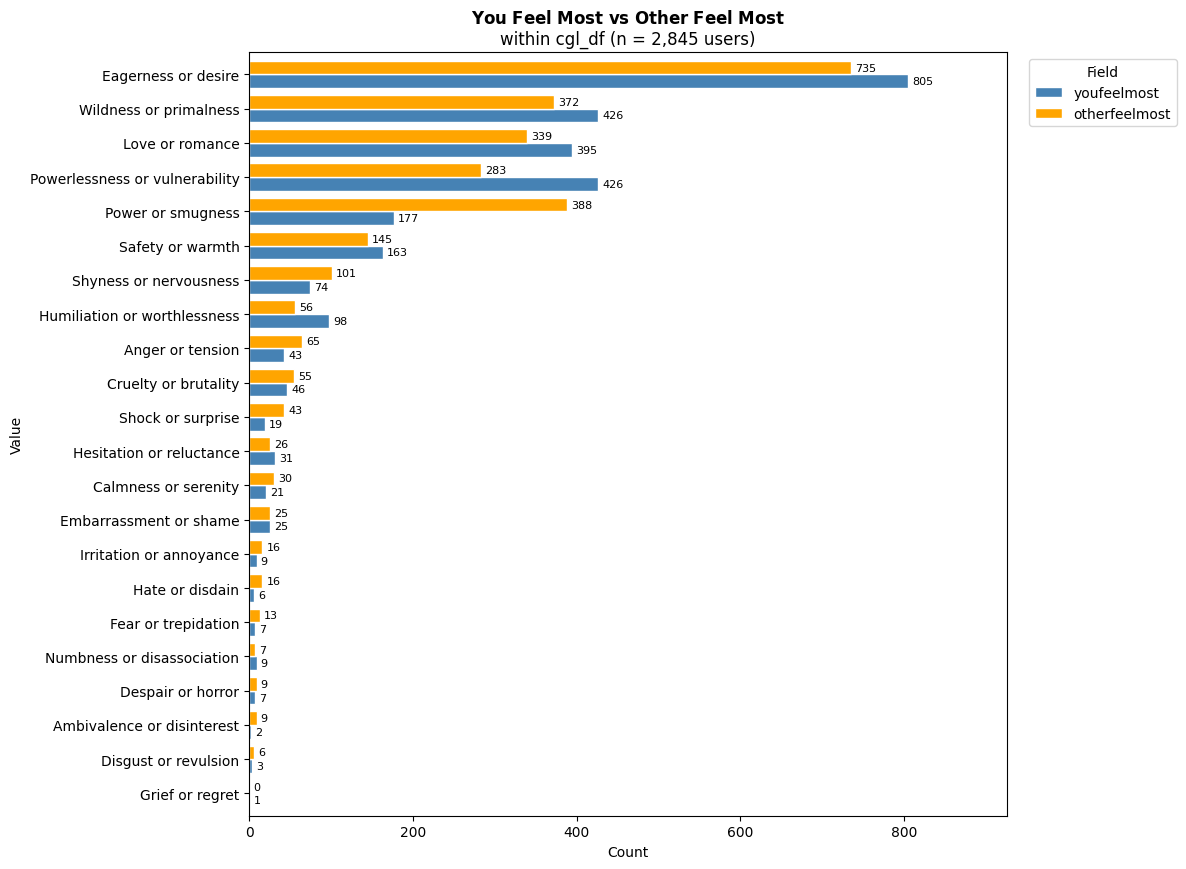

In [108]:
combined = pd.DataFrame({
    'youfeelmost': cgl_df['youfeelmost'].value_counts(),
    'otherfeelmost': cgl_df['otherfeel1most'].value_counts(),
}).fillna(0).astype(int)

# Sort by total count across both fields (ascending → highest at top)
combined = combined.loc[combined.sum(axis=1).sort_values(ascending=True).index]

# Plot grouped horizontal bar
fig, ax = plt.subplots(figsize=(12, max(6, len(combined) * 0.4)))
combined.plot(
    kind='barh',
    ax=ax,
    color=['steelblue', 'orange'],
    edgecolor='white',
    width=0.8,
)

ax.set_title(
    r"$\bf{You\ Feel\ Most\ vs\ Other\ Feel\ Most}$"
    f"\nwithin cgl_df (n = {len(cgl_df):,} users)"
)
ax.set_xlabel('Count')
ax.set_ylabel('Value')

# Count labels at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=8)

ax.legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')

xmax = combined.values.max()
if xmax > 0:
    ax.set_xlim(0, xmax * 1.15)

plt.tight_layout()
plt.show()


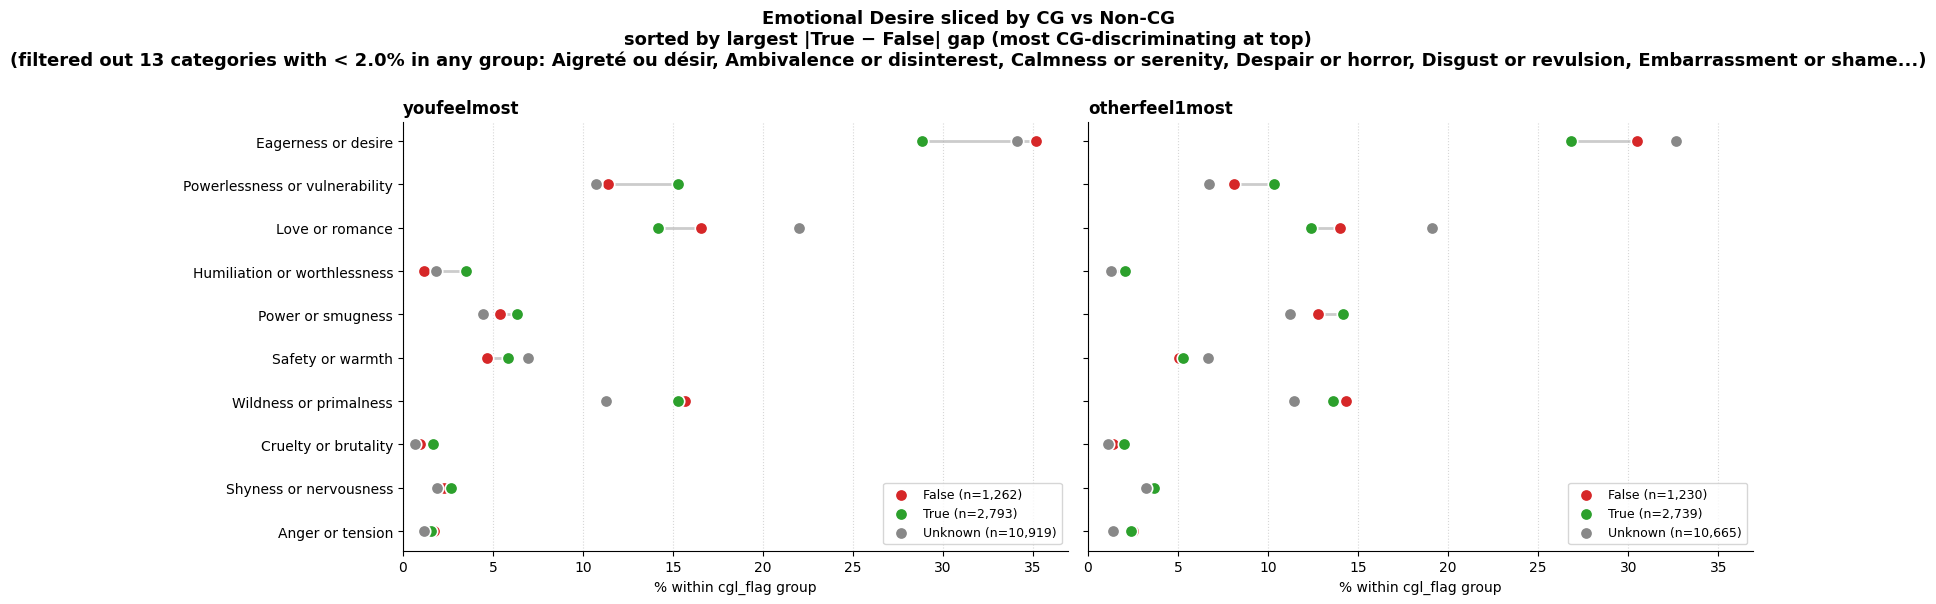

In [109]:
# === Adjust to match your columns ===
field_cols = ['youfeelmost', 'otherfeel1most']
MIN_PCT_THRESHOLD = 2.0  # drop categories where max % across all flags < this
# ====================================

# Build % within each cgl_flag group for each field
def build_pct(df, col):
    sub = df.dropna(subset=[col]).copy()
    sub['cgl_flag'] = sub['cgl_flag'].astype(str)
    pivot = pd.crosstab(sub[col], sub['cgl_flag'], normalize='columns').mul(100)
    return pivot.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)

pct_left = build_pct(df, field_cols[0])
pct_right = build_pct(df, field_cols[1])

# Union of categories, fill missing with 0
all_cats = pct_left.index.union(pct_right.index)
pct_left = pct_left.reindex(all_cats, fill_value=0)
pct_right = pct_right.reindex(all_cats, fill_value=0)

# (1) FILTER: drop categories where max % across all flags & both fields < threshold
max_per_cat = pd.concat([pct_left, pct_right], axis=1).max(axis=1)
kept_cats = max_per_cat[max_per_cat >= MIN_PCT_THRESHOLD].index
dropped_cats = max_per_cat[max_per_cat < MIN_PCT_THRESHOLD].index.tolist()
pct_left = pct_left.loc[kept_cats]
pct_right = pct_right.loc[kept_cats]

# (2) SORT: by max abs(True - False) across both fields, descending
abs_diff = pd.concat([
    (pct_left['True'] - pct_left['False']).abs(),
    (pct_right['True'] - pct_right['False']).abs(),
], axis=1).max(axis=1)
sort_order = abs_diff.sort_values(ascending=True).index  # ascending → biggest gap at top of barh
pct_left = pct_left.loc[sort_order]
pct_right = pct_right.loc[sort_order]

# n per cgl_flag group (for legend)
n_left = df.dropna(subset=[field_cols[0]])['cgl_flag'].astype(str).value_counts()
n_right = df.dropna(subset=[field_cols[1]])['cgl_flag'].astype(str).value_counts()

# (3) MATCH x-axis: shared scale across both panels
xmax = max(pct_left.values.max(), pct_right.values.max()) * 1.05

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.45 * len(sort_order))),
                          sharey=True, sharex=True)

color_map = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}

def plot_panel(ax, pct, title, n_counts):
    y_pos = np.arange(len(pct))
    for i, cat in enumerate(pct.index):
        ax.plot(
            [pct.loc[cat, 'False'], pct.loc[cat, 'True']],
            [i, i],
            color='#cccccc', linewidth=2, zorder=1,
        )
    for flag in ['False', 'True', 'Unknown']:
        ax.scatter(
            pct[flag].values, y_pos,
            color=color_map[flag], s=80, zorder=3,
            label=f'{flag} (n={int(n_counts.get(flag, 0)):,})',
            edgecolor='white', linewidth=1.2,
        )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(pct.index)
    ax.set_title(title, fontweight='bold', fontsize=12, loc='left')
    ax.set_xlabel('% within cgl_flag group')
    ax.set_xlim(0, xmax)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right', frameon=True, fontsize=9)

plot_panel(axes[0], pct_left, field_cols[0], n_left)
plot_panel(axes[1], pct_right, field_cols[1], n_right)

# Suptitle with summary of dropped categories
dropped_note = (
    f'\n(filtered out {len(dropped_cats)} categories with < {MIN_PCT_THRESHOLD}% '
    f'in any group: {", ".join(dropped_cats[:6])}'
    f'{"..." if len(dropped_cats) > 6 else ""})'
) if dropped_cats else ''
fig.suptitle(
    'Emotional Desire sliced by CG vs Non-CG\n'
    'sorted by largest |True − False| gap (most CG-discriminating at top)'
    + dropped_note,
    fontweight='bold', fontsize=13, y=1.0,
)

plt.tight_layout()
plt.show()


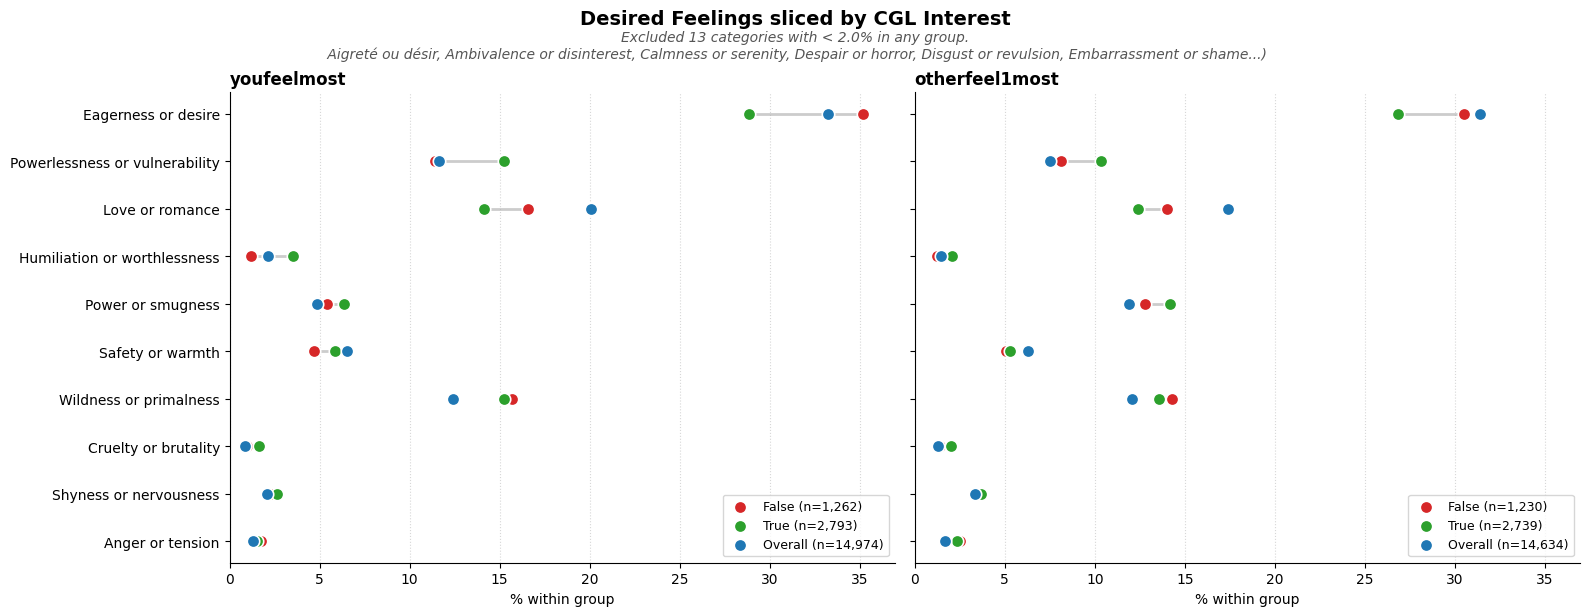

In [110]:
# === Adjust to match your columns ===
field_cols = ['youfeelmost', 'otherfeel1most']
MIN_PCT_THRESHOLD = 2.0  # drop categories where max % across all flags < this
# ====================================

# Build % within each cgl_flag group + a Total baseline column
def build_pct(df, col):
    sub = df.dropna(subset=[col]).copy()
    sub['cgl_flag'] = sub['cgl_flag'].astype(str)
    pivot = pd.crosstab(sub[col], sub['cgl_flag'], normalize='columns').mul(100)
    pivot = pivot.reindex(columns=['False', 'True', 'Unknown'], fill_value=0)
    # Total: % distribution across the entire field (all cgl_flag values combined)
    total_dist = sub[col].value_counts(normalize=True).mul(100)
    pivot['Overall'] = total_dist.reindex(pivot.index, fill_value=0)
    return pivot

pct_left = build_pct(df, field_cols[0])
pct_right = build_pct(df, field_cols[1])

# Union of categories
all_cats = pct_left.index.union(pct_right.index)
pct_left = pct_left.reindex(all_cats, fill_value=0)
pct_right = pct_right.reindex(all_cats, fill_value=0)

# (1) FILTER: drop categories where max % across all flags & both fields < threshold
max_per_cat = pd.concat([pct_left, pct_right], axis=1).max(axis=1)
kept_cats = max_per_cat[max_per_cat >= MIN_PCT_THRESHOLD].index
dropped_cats = max_per_cat[max_per_cat < MIN_PCT_THRESHOLD].index.tolist()
pct_left = pct_left.loc[kept_cats]
pct_right = pct_right.loc[kept_cats]

# (2) SORT: by max abs(True - False) across both fields, descending
abs_diff = pd.concat([
    (pct_left['True'] - pct_left['False']).abs(),
    (pct_right['True'] - pct_right['False']).abs(),
], axis=1).max(axis=1)
sort_order = abs_diff.sort_values(ascending=True).index  # ascending → biggest gap at top of barh
pct_left = pct_left.loc[sort_order]
pct_right = pct_right.loc[sort_order]

# n per cgl_flag group + total n (for legend)
n_left = df.dropna(subset=[field_cols[0]])['cgl_flag'].astype(str).value_counts()
n_right = df.dropna(subset=[field_cols[1]])['cgl_flag'].astype(str).value_counts()
n_left_total = df.dropna(subset=[field_cols[0]]).shape[0]
n_right_total = df.dropna(subset=[field_cols[1]]).shape[0]

# (3) MATCH x-axis: shared scale across both panels
xmax = max(pct_left.values.max(), pct_right.values.max()) * 1.05

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.45 * len(sort_order))),
                          sharey=True, sharex=True)

color_map = {'False': '#d62728', 'True': '#2ca02c', 'Overall': '#1f77b4'}

def plot_panel(ax, pct, title, n_counts, n_total):
    y_pos = np.arange(len(pct))
    # Connecting line between True and False
    for i, cat in enumerate(pct.index):
        ax.plot(
            [pct.loc[cat, 'False'], pct.loc[cat, 'True']],
            [i, i],
            color='#cccccc', linewidth=2, zorder=1,
        )
    # Dots for False, True, Total
    for flag in ['False', 'True', 'Overall']:
        n_label = n_total if flag == 'Overall' else int(n_counts.get(flag, 0))
        ax.scatter(
            pct[flag].values, y_pos,
            color=color_map[flag], s=80, zorder=3,
            label=f'{flag} (n={n_label:,})',
            edgecolor='white', linewidth=1.2,
        )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(pct.index)
    ax.set_title(title, fontweight='bold', fontsize=12, loc='left')
    ax.set_xlabel('% within group')
    ax.set_xlim(0, xmax)
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right', frameon=True, fontsize=9)

plot_panel(axes[0], pct_left, field_cols[0], n_left, n_left_total)
plot_panel(axes[1], pct_right, field_cols[1], n_right, n_right_total)

# Suptitle with note about filtered categories
dropped_note = (
    f'\nExcluded {len(dropped_cats)} categories with < {MIN_PCT_THRESHOLD}% '
    f'in any group.\n {", ".join(dropped_cats[:6])}'
    f'{"..." if len(dropped_cats) > 6 else ""})'
) 
# if dropped_cats else ''
# fig.suptitle(
#     'Desired Feelings sliced by CGL Interest\n'
#     + dropped_note,
#     fontweight='bold', fontsize=13, y=1.0,
# )

fig.suptitle(
    'Desired Feelings sliced by CGL Interest',
    fontweight='bold', fontsize=14, y=1.02,
)
if dropped_note:
    fig.text(
        0.5, 0.985, dropped_note.lstrip('\n'),
        ha='center', va='top',
        fontsize=10, color='#555555', style='italic',
    )


plt.tight_layout()
plt.show()


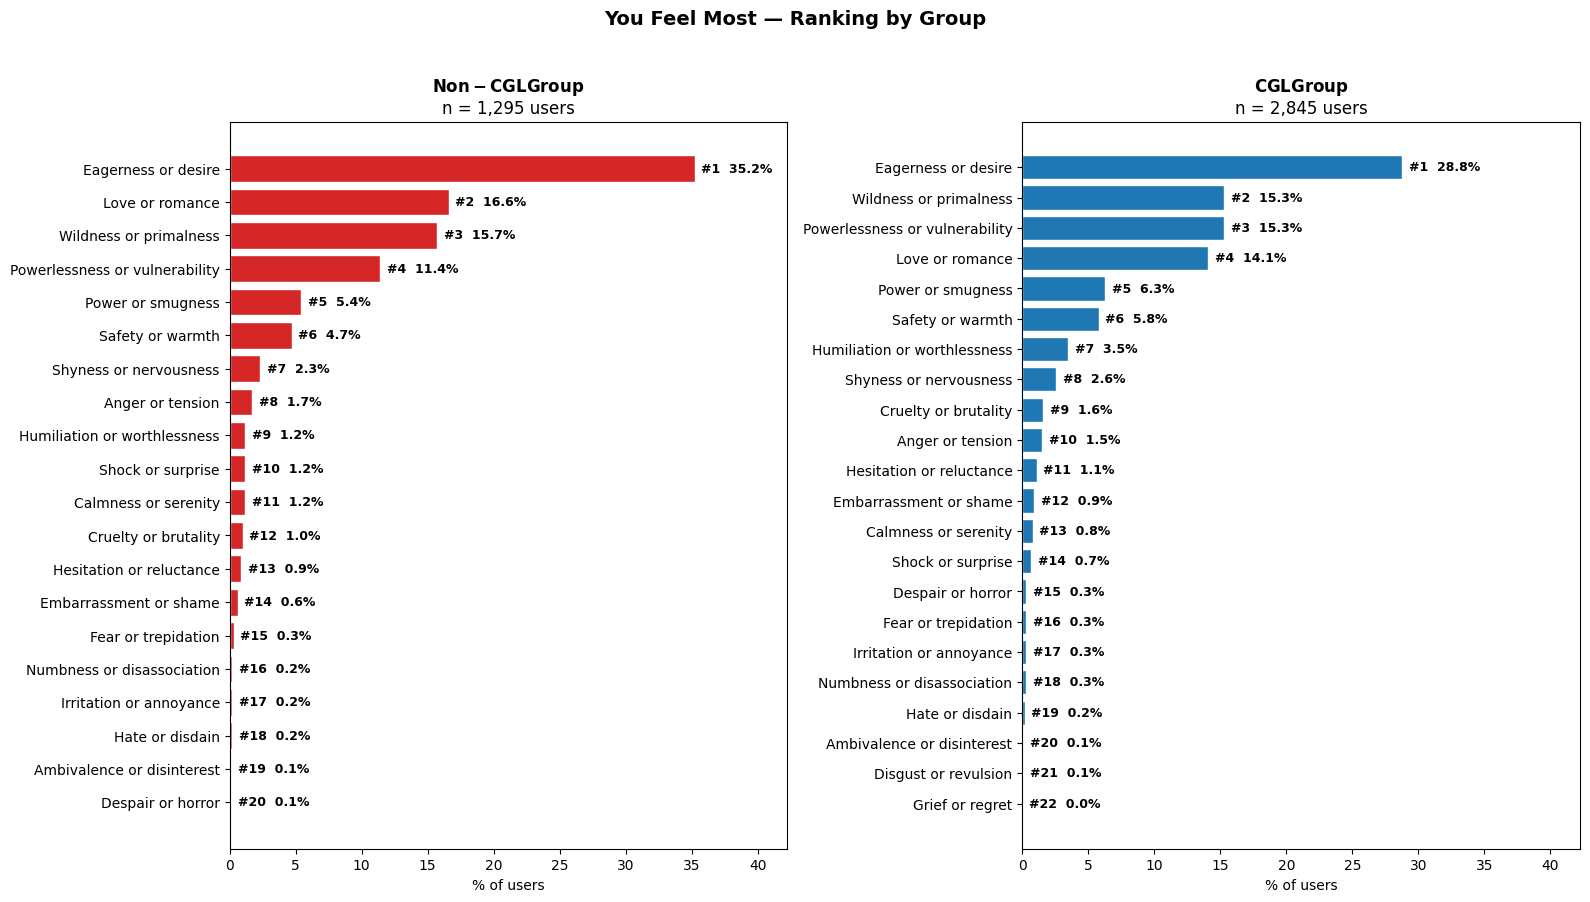

In [111]:
def get_pct_ranked(df_subset):
    return (
        df_subset['youfeelmost']
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .sort_values(ascending=True)   # ascending → highest at top of barh
    )

non_cgl_pct = get_pct_ranked(non_cgl_df)
cgl_pct = get_pct_ranked(cgl_df)

# Use a shared xlim so bar widths compare visually
shared_xmax = max(non_cgl_pct.max(), cgl_pct.max()) * 1.20

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, max(len(non_cgl_pct), len(cgl_pct)) * 0.4)))

for ax, pct, title, n, color in [
    (axes[0], non_cgl_pct, 'Non-CGL Group',  len(non_cgl_df), '#d62728'),
    (axes[1], cgl_pct,     'CGL Group',      len(cgl_df),     '#1f77b4'),
]:
    ax.barh(pct.index, pct.values, color=color, edgecolor='white')
    ax.set_title(f"$\\bf{{{title}}}$\nn = {n:,} users", fontsize=12)
    ax.set_xlabel('% of users')
    ax.set_xlim(0, shared_xmax)

    # Rank numbers + % values  ("#1  31.4%")
    n_items = len(pct)
    for i, (label, value) in enumerate(zip(pct.index, pct.values)):
        rank = n_items - i      # i=0 is the bottom, which is the lowest-ranked
        ax.text(value + 0.5, i, f'#{rank}  {value:.1f}%', va='center', fontsize=9, fontweight='bold')

axes[0].set_ylabel('')
axes[1].set_ylabel('')

fig.suptitle('You Feel Most — Ranking by Group', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Personality

### OCEAN

#### Variables & Functions

In [112]:
# OCEAN: the canonical Big Five personality traits.
# Powerlessness shares the same Likert-style scale but is NOT one of the Big Five —
# it's a kink-adjacent self-report kept in its own list so we don't accidentally
# treat it as a personality trait. See the Powerlessness subsection below.
ocean_cols = ['openness', 'consciensiousness', 'extroversion',
              'neuroticism', 'agreeableness']
power_cols = ['powerlessness']

def expanded_bucket_score(score):
    if score < -3:
        return 'Strong Disagree'
    elif score < 0:
        return 'Disagree'
    elif score == 0:
        return 'Neutral'
    elif score <= 3:
        return 'Agree'
    else:
        return 'Strong Agree'

expanded_bucket_order = ['Strong Disagree', 'Disagree', 'Neutral', 'Agree', 'Strong Agree']

def bucket_score_3(score):
    if score < 0:
        return 'Disagree'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Agree'

bucket_order_3 = ['Disagree', 'Neutral', 'Agree']


#### Analysis

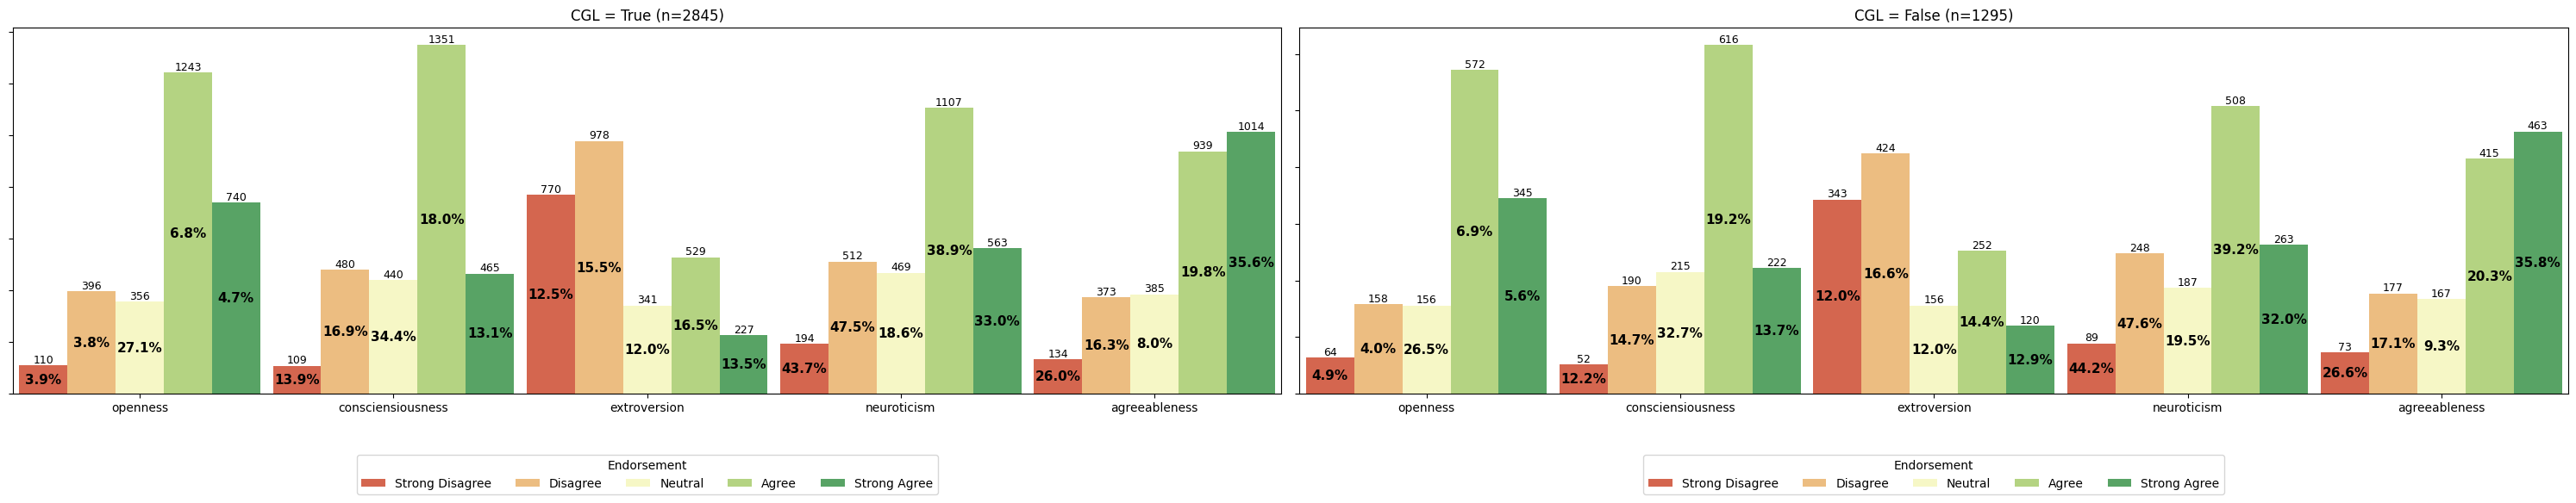

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(30, 6))

for idx, (cgl_flag, ax) in enumerate([('True', axes[0]), ('False', axes[1])]):
    subset = df[df['cgl_flag'].astype(str) == cgl_flag]
    bucket_data = []
    
    for trait in ocean_cols:
        trait_data = subset[trait].dropna()
        
        for score in trait_data:
            bucket = expanded_bucket_score(score)
            bucket_data.append({'trait': trait, 'bucket': bucket})
    
    bucket_df = pd.DataFrame(bucket_data)
    counts = bucket_df.groupby(['trait', 'bucket']).size().reset_index(name='count')
    
    # Calculate percentages within each trait
    counts['total'] = counts.groupby('trait')['count'].transform('sum')
    counts['pct'] = (100 * counts['count'] / counts['total']).round(1)
    
    counts['bucket'] = pd.Categorical(counts['bucket'], categories=expanded_bucket_order, ordered=True)
    counts['trait'] = pd.Categorical(counts['trait'], categories=ocean_cols, ordered=True)
    counts = counts.sort_values(['trait', 'bucket'])
    
    # Plot with wider bars
    sns.barplot(data=counts, x='trait', y='count', hue='bucket', ax=ax,
                palette='RdYlGn', hue_order=expanded_bucket_order, width=0.95)
    
    # Add count labels on top
    for container in ax.containers:
        ax.bar_label(container, fontsize=9)
    
    # Add percentage labels in middle of bars
    for bar, pct in zip(ax.patches, counts['pct']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height / 2,
                f'{pct:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    
    title = f'CGL = {cgl_flag} (n={len(subset)})'
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_yticklabels([])
    
    ax.legend(title='Endorsement', bbox_to_anchor=(0.5, -0.15),
              loc='upper center', ncol=5)

plt.tight_layout()
plt.show()


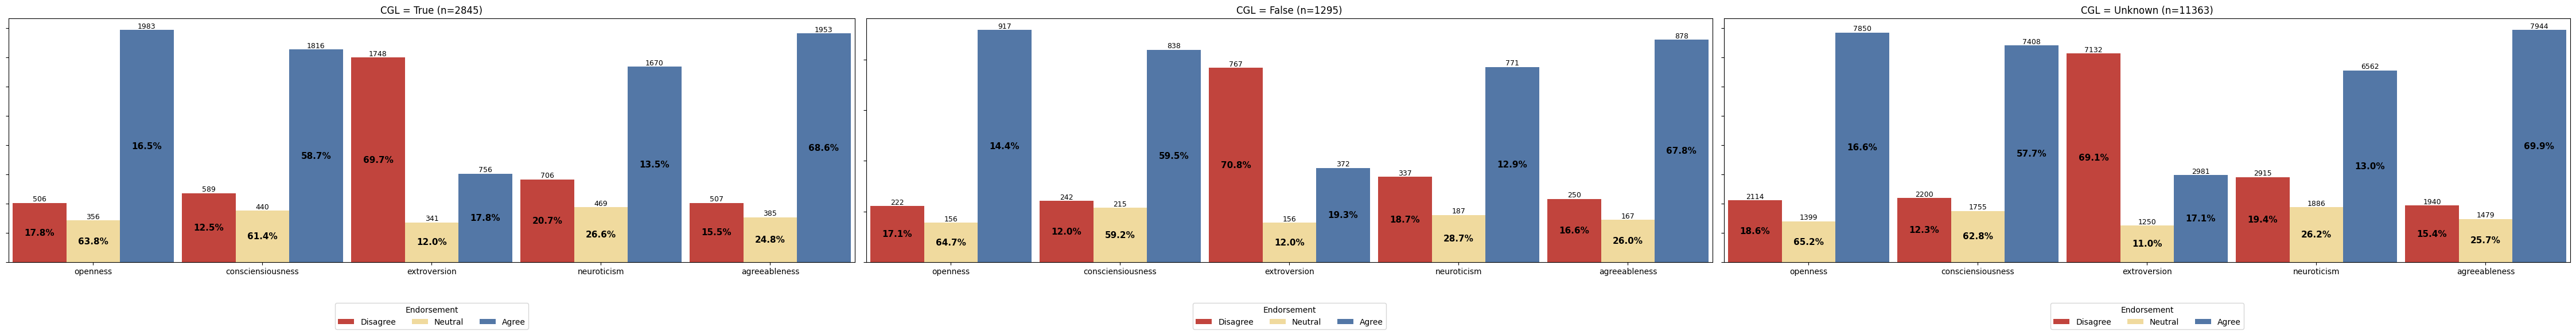

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(45, 6))

for idx, (cgl_flag, ax) in enumerate([('True', axes[0]), ('False', axes[1]), ('Unknown', axes[2])]):
    subset = df[df['cgl_flag'].astype(str) == cgl_flag]
    bucket_data = []
    
    for trait in ocean_cols:
        trait_data = subset[trait].dropna()
        
        for score in trait_data:
            bucket = bucket_score_3(score)
            bucket_data.append({'trait': trait, 'bucket': bucket})
    
    bucket_df = pd.DataFrame(bucket_data)
    counts = bucket_df.groupby(['trait', 'bucket']).size().reset_index(name='count')
    
    counts['total'] = counts.groupby('trait')['count'].transform('sum')
    counts['pct'] = (100 * counts['count'] / counts['total']).round(1)
    
    counts['bucket'] = pd.Categorical(counts['bucket'], categories=bucket_order_3, ordered=True)
    counts['trait'] = pd.Categorical(counts['trait'], categories=ocean_cols, ordered=True)
    counts = counts.sort_values(['trait', 'bucket'])
    
    sns.barplot(data=counts, x='trait', y='count', hue='bucket', ax=ax,
                palette=['#d73027', '#fee090', '#4575b4'], hue_order=bucket_order_3, width=0.95)
    
    for container in ax.containers:
        ax.bar_label(container, fontsize=9)
    
    for bar, pct in zip(ax.patches, counts['pct']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height / 2,
                f'{pct:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')
    
    ax.set_title(f'CGL = {cgl_flag} (n={len(subset)})', fontsize=12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_yticklabels([])
    ax.legend(title='Endorsement', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_458401/2686702231.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_458401/2686702231.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_458401/2686702231.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_458401/2686702231.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_458401/2686702231.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

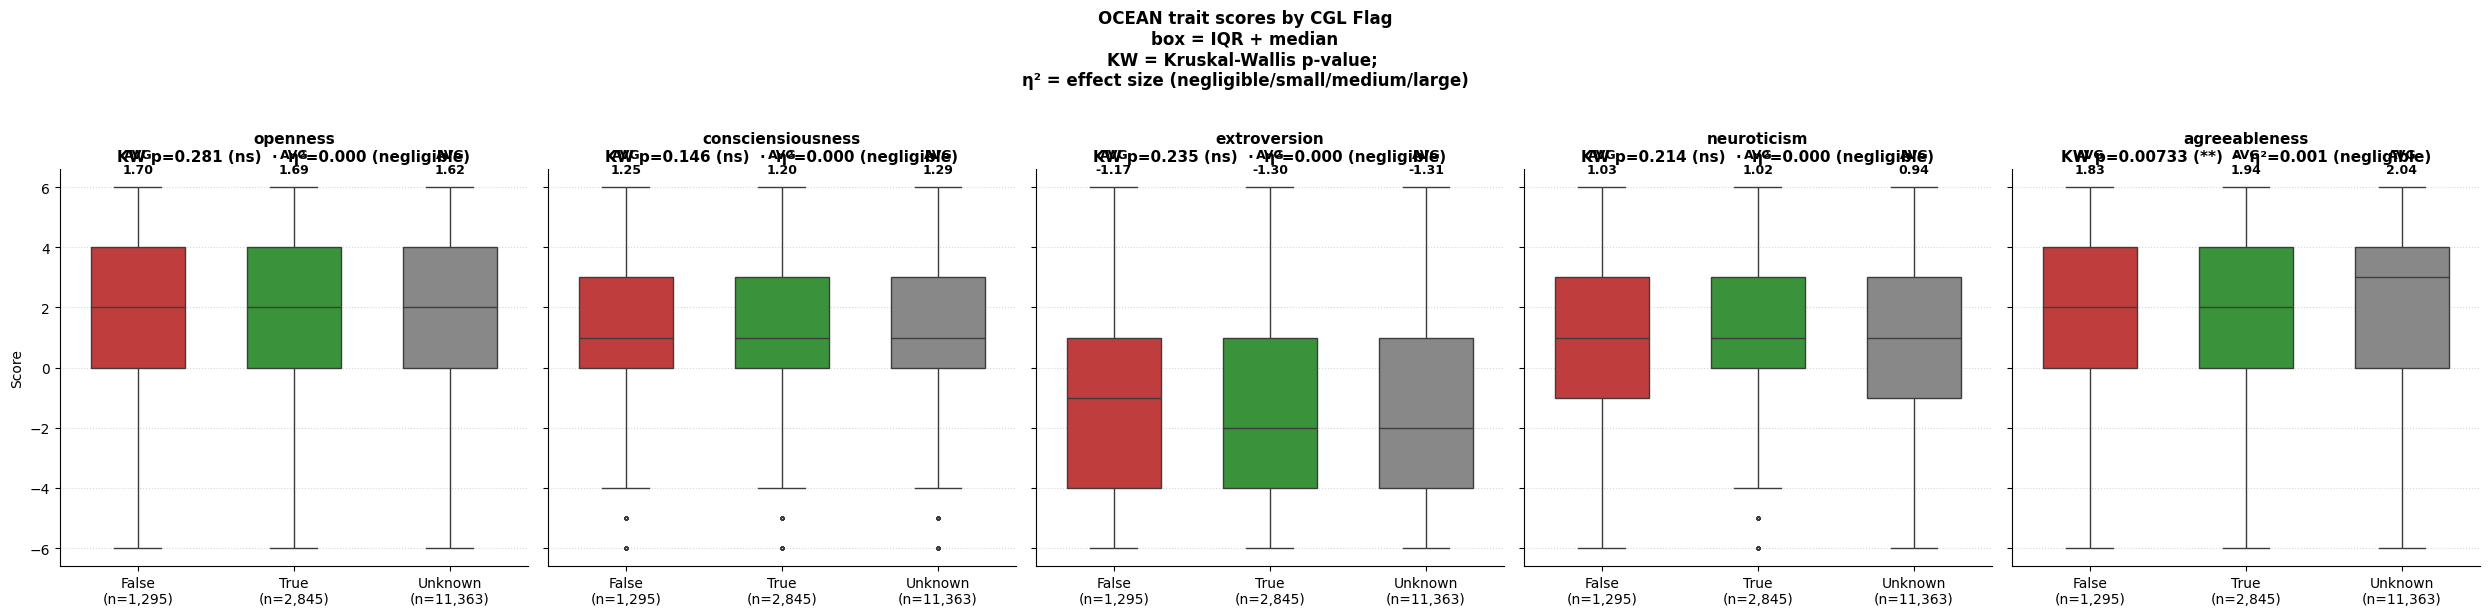

In [115]:
plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)

flag_order = ['False', 'True', 'Unknown']
palette = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}

n_per_flag = plot_df['cgl_flag'].value_counts()


def eta_squared_kw(h_stat, k, n):
    """Eta-squared effect size for Kruskal-Wallis."""
    return max(0.0, (h_stat - k + 1) / (n - k)) if n > k else 0.0


def interpret_eta(e):
    if e < 0.01: return 'negligible'
    if e < 0.06: return 'small'
    if e < 0.14: return 'medium'
    return 'large'


fig, axes = plt.subplots(1, len(ocean_cols), figsize=(5 * len(ocean_cols), 6), sharey=True)

for ax, trait in zip(axes, ocean_cols):
    sub = plot_df[['cgl_flag', trait]].dropna()
    
    sns.boxplot(
        data=sub, x='cgl_flag', y=trait,
        order=flag_order, palette=palette, ax=ax,
        width=0.6, fliersize=2,
    )

    # Mean as number above each box
    means = sub.groupby('cgl_flag')[trait].mean().reindex(flag_order)
    y_max = sub[trait].max()
    y_min = sub[trait].min()
    text_y = y_max + (y_max - y_min) * 0.03
    for i, m in enumerate(means.values):
        if pd.notna(m):
            ax.text(i, text_y, f'AVG\n{m:.2f}',
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='black')

    # Kruskal-Wallis + eta-squared effect size
    groups = [sub.loc[sub['cgl_flag'] == f, trait].values for f in flag_order]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        n_total = sum(len(g) for g in groups)
        eta = eta_squared_kw(stat, len(groups), n_total)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(
            f'{trait}\n'
            f'KW p={p:.3g} ({sig})  ·  η²={eta:.3f} ({interpret_eta(eta)})',
            fontsize=11, fontweight='bold',
        )
    else:
        ax.set_title(trait, fontsize=11, fontweight='bold')

    xtick_labels = [f'{f}\n(n={int(n_per_flag.get(f, 0)):,})' for f in flag_order]
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel('')
    ax.set_ylabel('Score' if ax is axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle(
    'OCEAN trait scores by CGL Flag\n'
    'box = IQR + median'
    '\nKW = Kruskal-Wallis p-value; ' \
    '\nη² = effect size (negligible/small/medium/large)',
    fontweight='bold', fontsize=12, y=1.02,
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_458401/4141820961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_458401/4141820961.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_458401/4141820961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_458401/4141820961.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)
/tmp/ipykernel_458401/4141820961.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

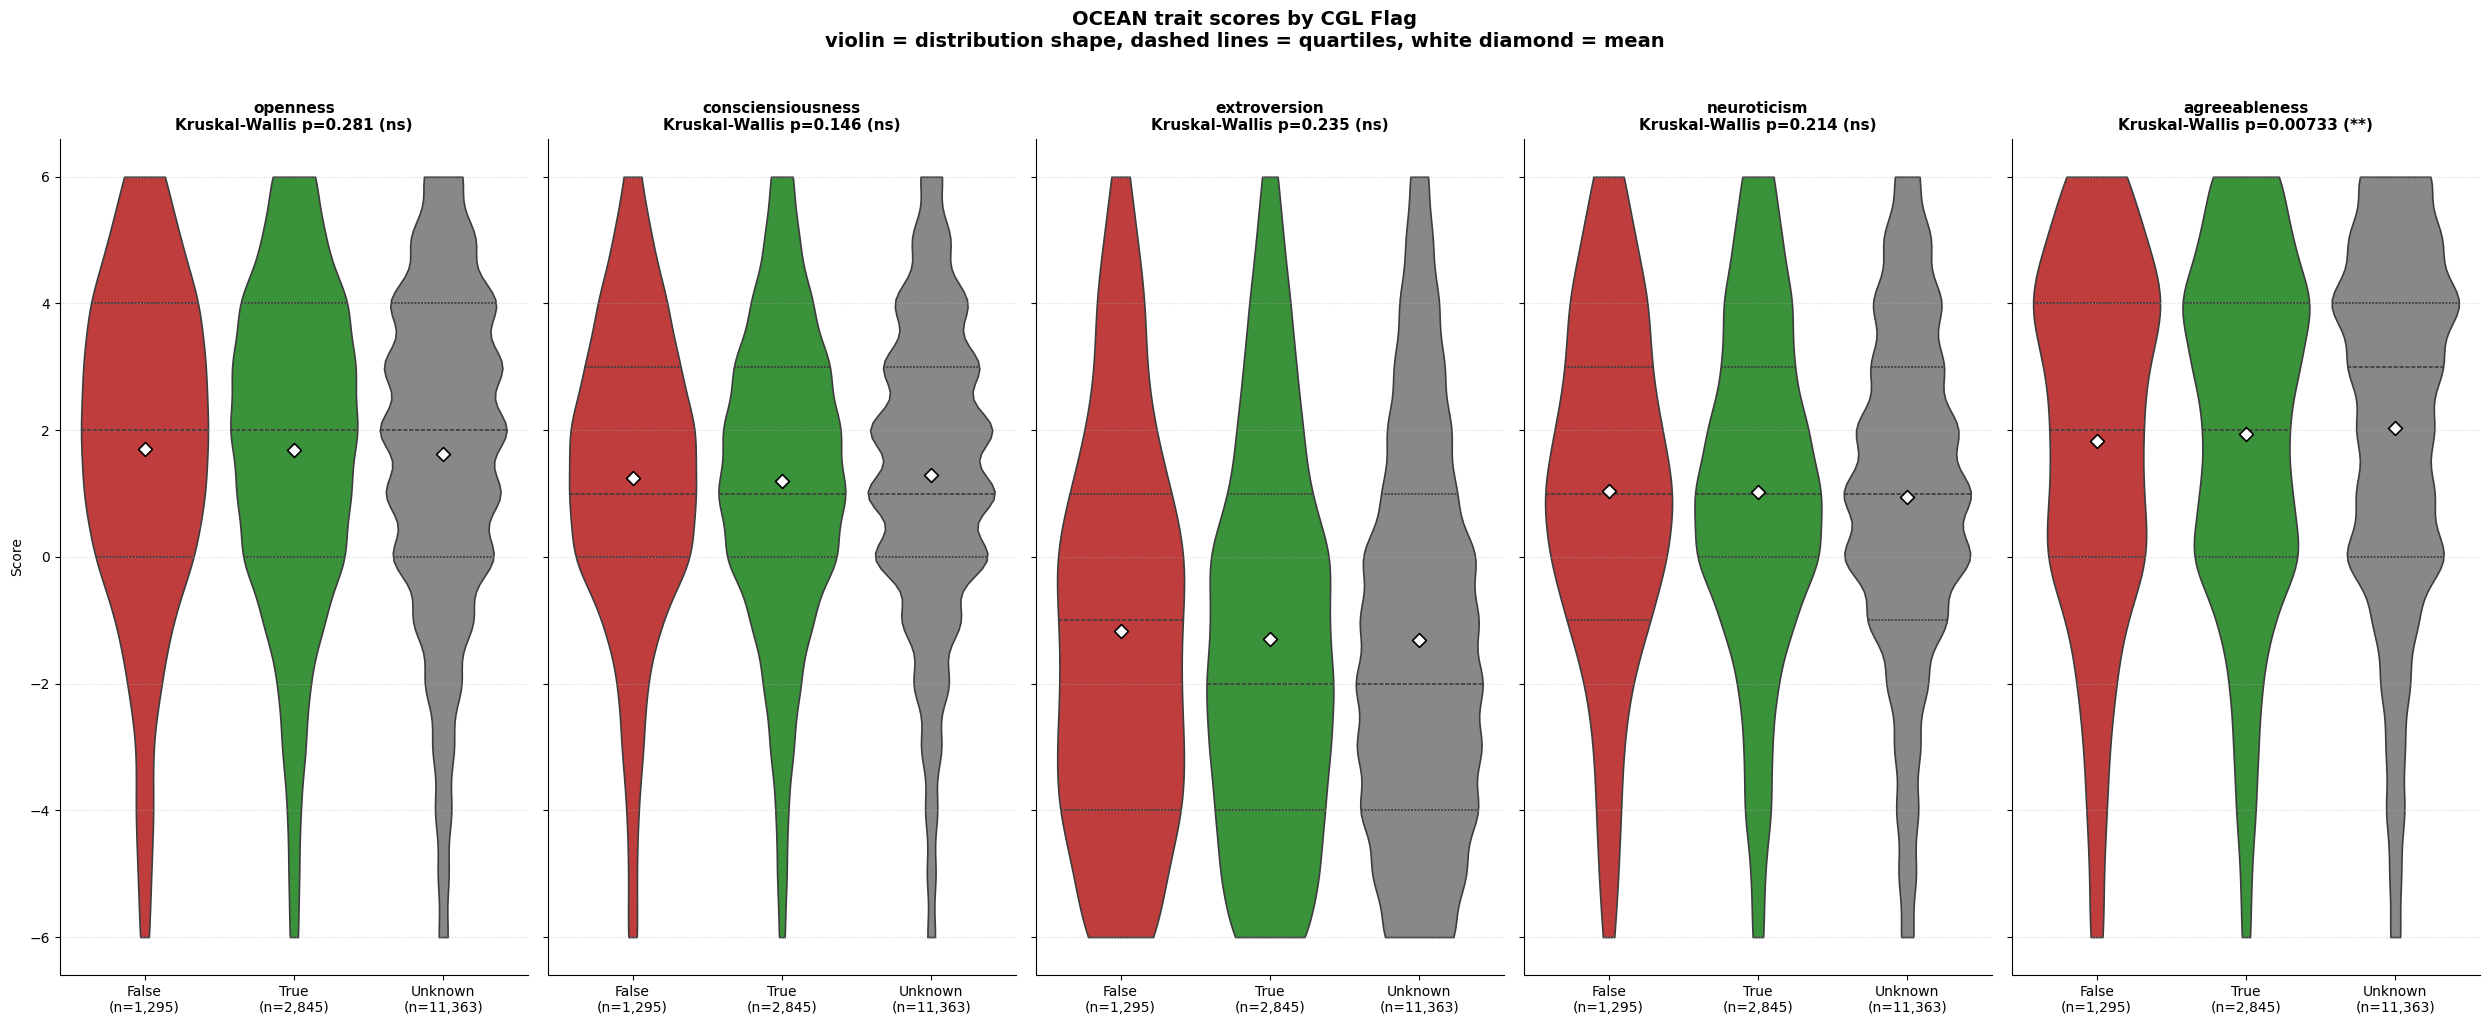

In [116]:
# Use string-form cgl_flag for robust comparison
plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)

flag_order = ['False', 'True', 'Unknown']
palette = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}

# Group n counts (for x-axis labels)
n_per_flag = plot_df['cgl_flag'].value_counts()

# Layout: one panel per OCEAN trait
fig, axes = plt.subplots(1, len(ocean_cols), figsize=(5 * len(ocean_cols), 10), sharey=True)

for ax, trait in zip(axes, ocean_cols):
    sub = plot_df[['cgl_flag', trait]].dropna()
    
    sns.violinplot(
        data=sub, x='cgl_flag', y=trait,
        order=flag_order, palette=palette, ax=ax,
        inner='quartile',  # shows quartile lines inside the violin
        cut=0,             # don't extend density past the actual data range
        linewidth=1.2,
        width=0.85,
    )
    
    # Overlay mean marker (white diamond) since violin doesn't show it by default
    means = sub.groupby('cgl_flag')[trait].mean().reindex(flag_order)
    ax.scatter(range(len(flag_order)), means.values,
               marker='D', s=50, color='white',
               edgecolor='black', linewidth=1.2, zorder=10)

    # Kruskal-Wallis test across the 3 groups
    groups = [sub.loc[sub['cgl_flag'] == f, trait].values for f in flag_order]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'{trait}\nKruskal-Wallis p={p:.3g} ({sig})',
                     fontsize=11, fontweight='bold')
    else:
        ax.set_title(trait, fontsize=11, fontweight='bold')

    # n= under each x-tick label
    xtick_labels = [
        f'{f}\n(n={int(n_per_flag.get(f, 0)):,})' for f in flag_order
    ]
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel('')
    ax.set_ylabel('Score' if ax is axes[0] else '')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle(
    'OCEAN trait scores by CGL Flag\n'
    'violin = distribution shape, dashed lines = quartiles, white diamond = mean',
    fontweight='bold', fontsize=14, y=1.02,
)

plt.tight_layout()
plt.show()


### Powerlessness (kink-adjacent, not OCEAN)

Powerlessness shares the same Likert scale as the Big Five but is **not** part of OCEAN. It is analyzed in its own subsection because:

1. **Construct**: OCEAN traits (Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism) describe stable personality dimensions. Powerlessness is closer to a kink-relevant attitudinal self-report.
2. **Audience clarity**: a 6-trait "OCEAN" is a construct error for technical readers (peer reviewers, psychologists) and confusing for non-technical readers (anyone Googling OCEAN gets five traits).
3. **Headline question is different**: OCEAN was tested as a predictor of CGL identification (it isn't). The headline question for Powerlessness is whether it tracks **D/s preference** — something we never expected the Big Five to do.

The plots below mirror the OCEAN visualizations so the two constructs can still be compared at a glance.


/tmp/ipykernel_458401/1970937546.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_458401/1970937546.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


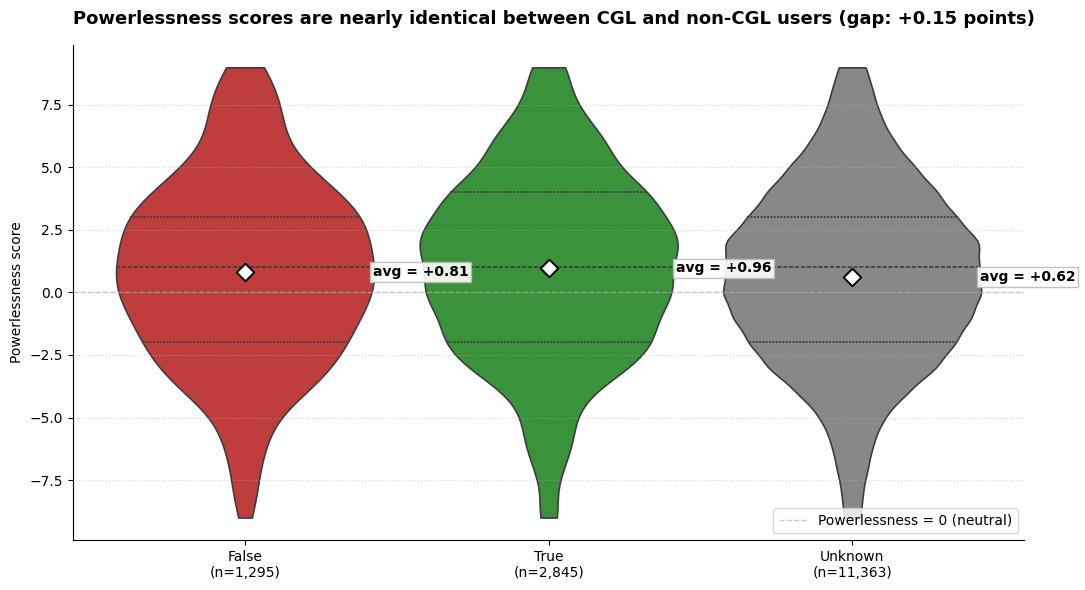


Stats (for curious readers)
───────────────────────────
Kruskal-Wallis omnibus across the 3 CGL groups: H = 22.1, p = 1.59e-05 (***)
Effect size η² = 0.001  (negligible <0.01 · small <0.06 · medium <0.14 · large ≥0.14)

With this n, even a tiny gap can be 'statistically significant'. The magnitude
(0.15 points on the Powerlessness scale) is what tells you whether the
difference matters in practice.



In [117]:
# Powerlessness — distribution by CGL flag.
# Headline finding sits in the title; the chart confirms it visually.
plot_df = df.copy()
plot_df['cgl_flag'] = plot_df['cgl_flag'].astype(str)

flag_order = ['False', 'True', 'Unknown']
palette = {'False': '#d62728', 'True': '#2ca02c', 'Unknown': '#888888'}
n_per_flag = plot_df['cgl_flag'].value_counts()

sub = plot_df[['cgl_flag', 'powerlessness']].dropna()
means = sub.groupby('cgl_flag')['powerlessness'].mean()

# Compute the headline finding before plotting.
gap = means.get('True', float('nan')) - means.get('False', float('nan'))
if abs(gap) < 0.3:
    headline = (
        f'Powerlessness scores are nearly identical between CGL and non-CGL users '
        f'(gap: {gap:+.2f} points)'
    )
else:
    direction = 'HIGHER' if gap > 0 else 'LOWER'
    headline = (
        f'CGL users score {abs(gap):.1f} points {direction} on Powerlessness '
        f'than non-CGL users'
    )

# One chart, not two. Violin is more intuitive than a box for a non-technical reader.
fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(
    data=sub, x='cgl_flag', y='powerlessness',
    order=flag_order, palette=palette, ax=ax,
    inner='quartile', cut=0, linewidth=1.2, width=0.85,
)

# Mean diamond + inline label on each violin
ax.scatter(
    range(len(flag_order)),
    [means.get(f, float('nan')) for f in flag_order],
    marker='D', s=80, color='white',
    edgecolor='black', linewidth=1.4, zorder=10,
)
for i, f in enumerate(flag_order):
    m = means.get(f, float('nan'))
    if pd.notna(m):
        ax.text(
            i + 0.42, m, f'avg = {m:+.2f}',
            ha='left', va='center', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='#bbbbbb', alpha=0.9, pad=2),
        )

ax.axhline(0, color='#aaa', linestyle='--', linewidth=1, alpha=0.6,
           label='Powerlessness = 0 (neutral)')

xtick_labels = [f'{f}\n(n={int(n_per_flag.get(f, 0)):,})' for f in flag_order]
ax.set_xticklabels(xtick_labels)
ax.set_xlabel('')
ax.set_ylabel('Powerlessness score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(loc='lower right', frameon=True)

ax.set_title(headline, fontweight='bold', fontsize=13, loc='left', pad=15)
plt.tight_layout()
plt.show()

# Stats kept out of the title — surfaced here for curious readers.
groups = [sub.loc[sub['cgl_flag'] == f, 'powerlessness'].values for f in flag_order]
groups = [g for g in groups if len(g) > 0]
stat, p = kruskal(*groups)
n_total = sum(len(g) for g in groups)
eta = max(0.0, (stat - len(groups) + 1) / (n_total - len(groups))) if n_total > len(groups) else 0.0
sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
print(f"""
Stats (for curious readers)
───────────────────────────
Kruskal-Wallis omnibus across the 3 CGL groups: H = {stat:.1f}, p = {p:.3g} ({sig})
Effect size η² = {eta:.3f}  (negligible <0.01 · small <0.06 · medium <0.14 · large ≥0.14)

With this n, even a tiny gap can be 'statistically significant'. The magnitude
({abs(gap):.2f} points on the Powerlessness scale) is what tells you whether the
difference matters in practice.
""")


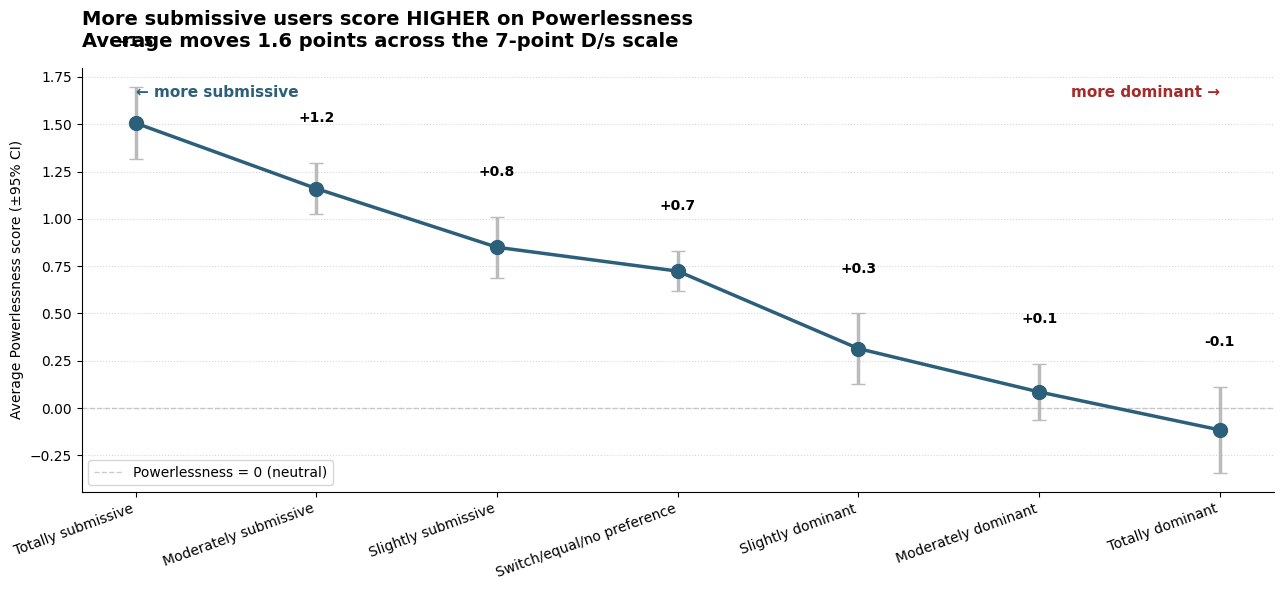


Stats (for curious readers)
───────────────────────────
Spearman ρ = -0.137  (***, n = 15,095)
  ρ near 0 → no relationship between Powerlessness and D/s preference
  ρ < 0    → higher Powerlessness goes with more SUBMISSIVE D/s preference
  ρ > 0    → higher Powerlessness goes with more DOMINANT D/s preference

A monotone slope across all 7 D/s levels (rather than just a sub-vs-dom split)
means Powerlessness behaves like a graded dimension, not a binary kink/no-kink
switch — the more submissive someone is, the higher their Powerlessness, level
by level.



In [118]:
# Powerlessness × D/s Preference — the headline question for this variable.
# Title carries the finding; chart confirms direction and shape; stats sit below.
from scipy.stats import spearmanr

sub = df[['powerlessness', 'ds_preference']].dropna().copy()
sub['ds_rank'] = sub['ds_preference'].map(ds_rank)

rho, p_rho = spearmanr(sub['ds_rank'], sub['powerlessness'])

grouped = (
    sub.groupby('ds_preference')['powerlessness']
       .agg(['mean', 'std', 'count'])
       .reindex(ds_order)
)
grouped['ci'] = 1.96 * grouped['std'] / np.sqrt(grouped['count'])

# Plain-language headline: how much does the average move across the scale?
sub_end = grouped.loc['Totally submissive', 'mean']
dom_end = grouped.loc['Totally dominant', 'mean']
range_pts = sub_end - dom_end
direction_word = 'HIGHER' if range_pts > 0 else 'LOWER'
headline = (
    f'More submissive users score {direction_word} on Powerlessness\n'
    f'Average moves {abs(range_pts):.1f} points from Totally Dominant '
    f'(left) to Totally Submissive (right)'
)
# ds_order has Totally submissive at index 0, Totally dominant at index 6 —
# so on the chart, sub is on the LEFT and dom is on the RIGHT. Update the
# headline accordingly:
headline = (
    f'More submissive users score {direction_word} on Powerlessness\n'
    f'Average moves {abs(range_pts):.1f} points across the 7-point D/s scale'
)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(ds_order))
ax.errorbar(
    x, grouped['mean'], yerr=grouped['ci'],
    fmt='o-', linewidth=2.5, markersize=10,
    color='#2c5f7a', ecolor='#bbbbbb', capsize=5,
)

# Inline mean labels above each point — no n=, kept clean.
for i, (_, row) in enumerate(grouped.iterrows()):
    if pd.notna(row['mean']):
        ax.text(
            i, row['mean'] + row['ci'] + 0.20,
            f'{row["mean"]:+.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
        )

ax.axhline(0, color='#aaa', linestyle='--', linewidth=1, alpha=0.6,
           label='Powerlessness = 0 (neutral)')

# Orientation labels in the upper corners — quick read on which side is which.
y_min, y_max = ax.get_ylim()
y_label_pos = y_max - (y_max - y_min) * 0.04
ax.text(0, y_label_pos, '← more submissive',
        ha='left', va='top', fontsize=11, fontweight='bold', color='#2c5f7a')
ax.text(len(ds_order) - 1, y_label_pos, 'more dominant →',
        ha='right', va='top', fontsize=11, fontweight='bold', color='#a52a2a')

ax.set_xticks(x)
ax.set_xticklabels(ds_order, rotation=20, ha='right')
ax.set_xlabel('')
ax.set_ylabel('Average Powerlessness score (±95% CI)')
ax.set_title(headline, fontweight='bold', fontsize=14, loc='left', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()

sig = '***' if p_rho < 0.001 else ('**' if p_rho < 0.01 else ('*' if p_rho < 0.05 else 'ns'))
print(f"""
Stats (for curious readers)
───────────────────────────
Spearman ρ = {rho:+.3f}  ({sig}, n = {len(sub):,})
  ρ near 0 → no relationship between Powerlessness and D/s preference
  ρ < 0    → higher Powerlessness goes with more SUBMISSIVE D/s preference
  ρ > 0    → higher Powerlessness goes with more DOMINANT D/s preference

A monotone slope across all 7 D/s levels (rather than just a sub-vs-dom split)
means Powerlessness behaves like a graded dimension, not a binary kink/no-kink
switch — the more submissive someone is, the higher their Powerlessness, level
by level.
""")


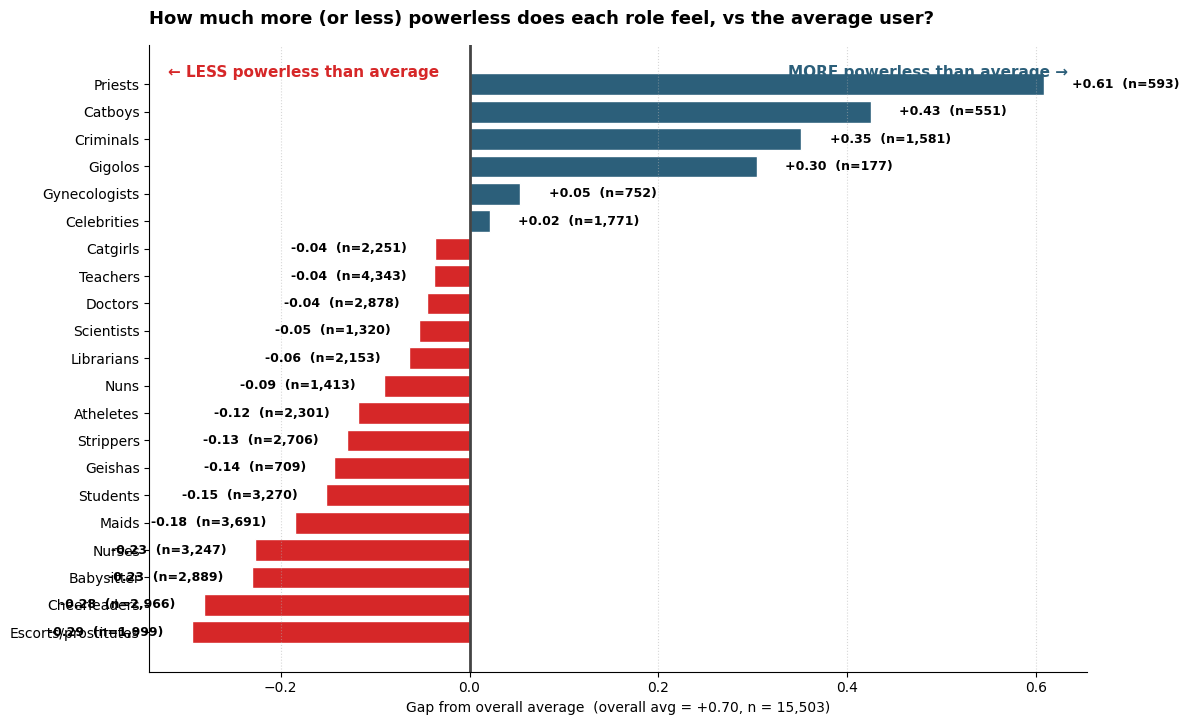


How to read this chart
──────────────────────
Each bar = the GAP between this role's average Powerlessness score and the
overall average (+0.70 for n = 15,503).
  +0.50 → users in this role score about half a point HIGHER than average
  -0.50 → users in this role score about half a point LOWER than average
   0.00 → this role's users feel as powerless as a typical respondent

Why a gap, not a raw score? It removes the cognitive step of comparing two
numbers. The chart reads as direction + magnitude in one glance.

Roles with fewer than 30 responders are excluded so the means stay stable.

Cross-reference: roles that lean strongly Sub on the Role vs D/s chart should
sit on the right (blue, MORE powerless) end here. Roles that lean Dom should
sit on the left (red, LESS powerless) end. A mismatch is the interesting case.



In [119]:
# Powerlessness × Role — show GAP FROM AVERAGE so readers don't have to
# mentally subtract two numbers. A reader sees "+0.4" and immediately knows
# both direction and size.
role_cols = df.filter(like='role_').columns.tolist()

overall_mean = df['powerlessness'].mean()
overall_n = df['powerlessness'].notna().sum()

power_by_role = []
for r_col in role_cols:
    role_sub = df[(df[r_col] == 1) & df['powerlessness'].notna()]
    if len(role_sub) >= 30:  # roles with too few responders → unstable mean
        power_by_role.append({
            'role': r_col.replace('role_', ''),
            'mean': role_sub['powerlessness'].mean(),
            'n': len(role_sub),
        })

power_role_df = (
    pd.DataFrame(power_by_role)
      .set_index('role')
      .assign(gap=lambda d: d['mean'] - overall_mean)
      .sort_values('gap')   # ascending → most negative at top of barh
)

fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(power_role_df))))
colors = ['#d62728' if g < 0 else '#2c5f7a' for g in power_role_df['gap']]
ax.barh(power_role_df.index, power_role_df['gap'],
        color=colors, edgecolor='white')
ax.axvline(0, color='#444', linestyle='-', linewidth=2)

# Bar-end labels — gap and n
for i, (_, row) in enumerate(power_role_df.iterrows()):
    offset = 0.03 if row['gap'] >= 0 else -0.03
    ha = 'left' if row['gap'] >= 0 else 'right'
    ax.text(
        row['gap'] + offset, i,
        f'{row["gap"]:+.2f}  (n={int(row["n"]):,})',
        va='center', ha=ha, fontsize=9, fontweight='bold',
    )

# Orientation labels at the top of each side
xlim = ax.get_xlim()
top_y = len(power_role_df) - 0.3
ax.text(xlim[0] + (xlim[1] - xlim[0]) * 0.02, top_y,
        '← LESS powerless than average',
        ha='left', va='top', fontsize=11, fontweight='bold', color='#d62728')
ax.text(xlim[1] - (xlim[1] - xlim[0]) * 0.02, top_y,
        'MORE powerless than average →',
        ha='right', va='top', fontsize=11, fontweight='bold', color='#2c5f7a')

ax.set_xlabel(f'Gap from overall average  (overall avg = {overall_mean:+.2f}, n = {overall_n:,})')
ax.set_ylabel('')
ax.set_title(
    'How much more (or less) powerless does each role feel, vs the average user?',
    fontweight='bold', fontsize=13, loc='left', pad=15,
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"""
How to read this chart
──────────────────────
Each bar = the GAP between this role's average Powerlessness score and the
overall average ({overall_mean:+.2f} for n = {overall_n:,}).
  +0.50 → users in this role score about half a point HIGHER than average
  -0.50 → users in this role score about half a point LOWER than average
   0.00 → this role's users feel as powerless as a typical respondent

Why a gap, not a raw score? It removes the cognitive step of comparing two
numbers. The chart reads as direction + magnitude in one glance.

Roles with fewer than 30 responders are excluded so the means stay stable.

Cross-reference: roles that lean strongly Sub on the Role vs D/s chart should
sit on the right (blue, MORE powerless) end here. Roles that lean Dom should
sit on the left (red, LESS powerless) end. A mismatch is the interesting case.
""")


# Summary

We tested whether CGL identification is predicted by Big Five personality structure (Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism). Across all five OCEAN traits, standardized mean differences between CGL and non-CGL users were trivial (all |d| < 0.10), indicating that broad personality structure does not meaningfully differentiate CGL-identifying users from the rest of the sample. CGL identification appears to be orthogonal to personality as captured by the Big Five — it is better understood as a relational/behavioral preference than as a personality trait.

In [121]:
# Within-CGL personality differences — do caregivers vs littles differ on OCEAN?
# (Powerlessness is now analyzed in its own subsection above.)
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].agg(['mean', 'std'])
print(within_cgl)


                                          openness            \
                                              mean       std   
soft_erotic_caretaker/caretakee dynamics                       
0                                         1.658741  2.588395   
1                                         1.803136  2.467504   

                                         consciensiousness            \
                                                      mean       std   
soft_erotic_caretaker/caretakee dynamics                               
0                                                 1.196830  2.370990   
1                                                 1.221254  2.495686   

                                         extroversion           neuroticism  \
                                                 mean       std        mean   
soft_erotic_caretaker/caretakee dynamics                                      
0                                           -1.209159  3.025126    0.959489   
1 

In [122]:
# 2. Within-CGL personality differences — do caregivers vs littles differ?
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].agg(['mean', 'std'])
print(within_cgl)


                                          openness            \
                                              mean       std   
soft_erotic_caretaker/caretakee dynamics                       
0                                         1.658741  2.588395   
1                                         1.803136  2.467504   

                                         consciensiousness            \
                                                      mean       std   
soft_erotic_caretaker/caretakee dynamics                               
0                                                 1.196830  2.370990   
1                                                 1.221254  2.495686   

                                         extroversion           neuroticism  \
                                                 mean       std        mean   
soft_erotic_caretaker/caretakee dynamics                                      
0                                           -1.209159  3.025126    0.959489   
1 

In [123]:
# Map ordinal variety categories to numeric (1-7)
variety_7_map = {
    'Very narrow': 1,
    'A little narrow': 2,
    'Somewhat narrow': 3,
    'Equally narrow and broad': 4,
    'A little broad': 5,
    'Somewhat broad': 6,
    'Very broad': 7,
}
df['variety_num'] = df['sexual_interest_variety'].map(variety_7_map)

# Sanity check — make sure mapping covered all values
print("Mapped values:", df['variety_num'].value_counts(dropna=False).sort_index())
print("Unmapped (NaN):", df['variety_num'].isna().sum())

# OCEAN vs variety: Spearman correlation
print("\n=== OCEAN vs Sexual Interest Variety (Spearman ρ) ===")
for trait in ocean_cols:
    mask = df[trait].notna() & df['variety_num'].notna()
    r = df.loc[mask, trait].corr(df.loc[mask, 'variety_num'], method='spearman')
    print(f"  {trait:20s} ρ = {r:+.3f}")



Mapped values: variety_num
1.0     643
2.0    1754
3.0    1261
4.0    3159
5.0    2603
6.0    3687
7.0    2392
NaN       4
Name: count, dtype: int64
Unmapped (NaN): 4

=== OCEAN vs Sexual Interest Variety (Spearman ρ) ===
  openness             ρ = +0.085
  consciensiousness    ρ = +0.004
  extroversion         ρ = +0.070
  neuroticism          ρ = -0.041
  agreeableness        ρ = +0.023


In [124]:
# 1. Roles vs variety — is it about WHAT you're into, not WHO you are?
role_cols = df.filter(like='role_').columns.tolist()
for r in role_cols:
    rho = df[r].corr(df['variety_num'], method='spearman')
    print(f"  {r.replace('role_','')}: ρ = {rho:+.2f}")


  Atheletes: ρ = +0.10
  Babysitter: ρ = +0.13
  Catboys: ρ = +0.07
  Catgirls: ρ = +0.13
  Celebrities: ρ = +0.10
  Cheerleaders: ρ = +0.13
  Criminals: ρ = +0.08
  Doctors: ρ = +0.10
  Escorts/prostitutes: ρ = +0.13
  Geishas: ρ = +0.08
  Gigolos: ρ = +0.04
  Gynecologists: ρ = +0.06
  Librarians: ρ = +0.10
  Maids: ρ = +0.13
  Nuns: ρ = +0.11
  Nurses: ρ = +0.13
  Priests: ρ = +0.05
  Scientists: ρ = +0.09
  Strippers: ρ = +0.14
  Students: ρ = +0.14
  Teachers: ρ = +0.12


In [125]:
# 2. Caretaker/caretakee dynamic vs variety — is the D-s structure the predictor?
print(df.groupby('soft_erotic_caretaker/caretakee dynamics')['variety_num'].agg(['mean', 'median', 'std', 'count']))


                                              mean  median       std  count
soft_erotic_caretaker/caretakee dynamics                                   
0                                         4.651957     5.0  1.722743  13846
1                                         4.863884     5.0  1.692880   1653


In [126]:
# 3. Within-CGL: does caretaker vs caretakee differ on personality?
within_cgl = cgl_df.groupby('soft_erotic_caretaker/caretakee dynamics')[ocean_cols].mean().T
print(within_cgl)


soft_erotic_caretaker/caretakee dynamics         0         1
openness                                  1.658741  1.803136
consciensiousness                         1.196830  1.221254
extroversion                             -1.209159 -1.648084
neuroticism                               0.959489  1.259582
agreeableness                             1.856891  2.250871


In [127]:
role_cols = df.filter(like='role_').columns.tolist()
role_variety = []
for r in role_cols:
    role_users = df.loc[df[r] == 1, 'variety_num'].dropna()
    non_role = df.loc[df[r] == 0, 'variety_num'].dropna()
    if len(role_users) > 30 and len(non_role) > 30:
        pooled_sd = ((role_users.std()**2 + non_role.std()**2) / 2) ** 0.5
        d = (role_users.mean() - non_role.mean()) / pooled_sd
        role_variety.append({
            'role': r.replace('role_', ''),
            'mean_with':  round(role_users.mean(), 2),
            'mean_without': round(non_role.mean(), 2),
            'd': round(d, 2),
            'n_with': len(role_users),
        })
print(pd.DataFrame(role_variety).sort_values('d', key=abs, ascending=False).to_string(index=False))


               role  mean_with  mean_without    d  n_with
Escorts/prostitutes       5.23          4.59 0.38    1999
            Geishas       5.28          4.65 0.38     709
               Nuns       5.26          4.62 0.38    1413
            Catboys       5.26          4.65 0.35     551
           Catgirls       5.16          4.59 0.34    2251
          Strippers       5.15          4.57 0.34    2706
       Cheerleaders       5.13          4.57 0.33    2966
           Students       5.10          4.56 0.32    3270
         Babysitter       5.11          4.58 0.31    2889
            Gigolos       5.21          4.67 0.31     177
             Nurses       5.08          4.57 0.30    3247
         Scientists       5.14          4.63 0.30    1320
              Maids       5.06          4.55 0.30    3691
        Celebrities       5.11          4.62 0.29    1771
          Atheletes       5.09          4.60 0.29    2301
         Librarians       5.09          4.61 0.28    2153
          Crim

In [128]:
df['n_roles'] = df[role_cols].sum(axis=1)
rho = df['n_roles'].corr(df['variety_num'], method='spearman')
print(f"Number of roles vs variety: ρ = {rho:.3f}")

Number of roles vs variety: ρ = 0.149


Variety preference is dose-dependent on role endorsement (ρ ≈ 0.X). Each additional role a respondent endorses corresponds to broader self-reported variety, regardless of role type. This suggests variety preference is best understood as a scalar measure of fantasy openness rather than a categorical kink-vs-vanilla distinction.

Variety preference isn't predicted by which role someone endorses — it's predicted by whether they endorse roles at all. The fact that single-role d is similar to or larger than total-role-count ρ is itself informative. It means "having any role" matters more than "having lots of roles." The relationship plateaus.

The fact that 21 different roles all produce ~0.3 effect sizes strongly suggests there's a single underlying construct doing the work: a general inclination toward role-based fantasy/play. The role columns are essentially measuring the same latent thing — "openness to role play" — and that latent thing is what correlates with variety.

The "0 vs any" boundary does most of the work — going from 0 to 1 role is a bigger jump than 1 to 5. The relationship may be non-linear.
People endorse multiple roles for reasons unrelated to variety — someone might have 8 roles all because they're into a specific aesthetic, not because they're "broad."

Compare effect sizes across all the things you've tested:

- Predictor of variety	Effect size
- Any single OCEAN trait	|ρ| ≤ 0.085 (trivial)
- CGL identification	d ≈ 0.10 (trivial)
- Caretaker dynamic	d ≈ 0.12 (trivial)
- Single role endorsement	d ≈ 0.23–0.38 (small)
- Number of roles endorsed	ρ = 0.15 (small, your best)


# Summary Doc Output

In [129]:
role_cols = df.filter(like='role_').columns.tolist()
df['n_roles'] = df[role_cols].sum(axis=1)

# Spearman: does endorsing more roles predict broader variety?
rho = df['n_roles'].corr(df['variety_num'], method='spearman')
print(f"n_roles vs variety: ρ = {rho:.3f}")

# Also: variety mean by number of roles
print("\nVariety by role count:")
print(df.groupby('n_roles')['variety_num'].agg(['mean', 'count']).round(2))


n_roles vs variety: ρ = 0.149

Variety by role count:
         mean  count
n_roles             
0        4.52  10111
1        4.70    102
2        4.39    224
3        4.60    339
4        4.74    424
5        4.68    514
6        4.75    487
7        4.94    519
8        4.97    487
9        5.14    484
10       5.00    397
11       5.17    356
12       5.34    264
13       5.22    225
14       5.45    192
15       5.53    115
16       5.36     91
17       5.51     67
18       5.76     37
19       5.55     31
20       5.86     14
21       5.68     19


In [130]:
# Generate findings summary markdown file if SHOW_SUMMARY is True
if SHOW_SUMMARY:
    summary_content = """
# CGL EDA Findings

## Overview
This document contains the key findings from the exploratory data analysis of the CGL dataset.

## Key Metrics
- Total records: {}
- CGL participants: {}
- Non-CGL participants: {}
""".format(
        len(df),
        (df['cgl_flag'] == True).sum(),
        (df['cgl_flag'] == False).sum()
    )
    
    with open('1a_CGL_EDA_Findings.md', 'w') as f:
        f.write(summary_content)
    print('✓ Findings summary saved to 1a_CGL_EDA_Findings.md')
else:
    print('Summary generation skipped (SHOW_SUMMARY = False)')

Summary generation skipped (SHOW_SUMMARY = False)
